<center>

<h1> MID TERM TEST 1 – WEEK 6 (15%) </h1>
<h2> DANA4830 - Dimension Reduction & Classification I </h2>
<h2> Summer Semester 2026 </h2>
<h2> Mid-term test 1 </h2>

</center>


<br>
<br>

**This section is to be filled out by the student.**

Date of the assessment : 14-06-2026

Student's First Name : leo

Student's Last Name L. Sanchez:

Student No. : 100440284

---

**INSTRUCTIONS TO CANDIDATES**

**_General Instructions_**

This mid-term test 1 has a total of **100 points.**

The duration of the mid-term test 1 is **1.5 week.**

<br>

**_Written-Answer and Submission Instructions_**

The answer should be confined to the context of the question.

Download the zip file and program in R/Python onto your local your computer. The codes and/or output will be included in the submission paper, and must demonstrate how you arrive at your answers.

Failure to attend to the assessment without valid reason will be given a zero mark.

Marks allocation: Question 1 has a weight of <span style="color:red; text-decoration: underline;">55 points</span>. Question 2 has a weight of <span style="color:red; text-decoration: underline;">20 points</span>. Question 3 has a weight of <span style="color:red; text-decoration: underline;">25 points</span>. if you replicate the reference paper in Question 1 strictly, you will receive a bonus with an addition of <span style="color:red; text-decoration: underline;">10% of your final score</span>.

---

<h3 style="font-weight: bold; text-align: left;">Question 1 <span style="float: right;">[55 points]</span></h3>



**<span style="color:red; font-weight: bold;">WRITE YOUR ANSWER BELOW</span>**

## Question 1 Answer — Figure 1(A) Pipeline

**Reference:** Syed et al. (2024), *Diagnostics* 14(11):1182.

**Track A:** GSE75214 (`PaperConfig` — SMOTE §3.7). **Track B:** Breast cancer (`ExamConfig` — RUS, no SMOTE).

Pipeline logic lives in importable module **`syed_pipeline/`** — one function per section §3.3–§3.12.


---
## 0. Environment Setup


In [1]:
import subprocess, sys, warnings
warnings.filterwarnings("ignore")
for pkg in ["pandas", "numpy", "scipy", "statsmodels", "matplotlib", "seaborn",
            "scikit-learn", "imbalanced-learn", "matplotlib-venn", "GEOparse", "xgboost", "mygene"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True)

import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))

# Reload local package (kernel may cache an older syed_pipeline)
for _mod in list(sys.modules):
    if _mod == "syed_pipeline" or _mod.startswith("syed_pipeline."):
        del sys.modules[_mod]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from syed_pipeline import (
    PaperConfig, ExamConfig, PipelineConfig,
    run_section32_preprocess, display_preprocessing_removals,
    run_section33_deg, run_section34_prepare, run_section34_prepare_on_train,
    run_section341_mi, run_section342_rfecv, run_section343_embedded,
    run_section344_complement,
    run_section35_hfcp, run_section36_split, run_section37_balance,
    run_section38_loocv, run_section39_train, run_section310_evaluate,
    run_section310_compare, slice_section36_genes, minmax_deg_matrix,
    run_section311_external, run_section312_pathway,
    run_pipeline, load_gse75214, load_breast_cancer,
    screened_consensus_genes, build_feature_sets, run_baseline_suite,
    run_all_models_baseline, run_univariate_quick_compare,
    top_deg_features_by_qvalue,
    compute_univariate_scores, build_univariate_rank_table, plot_univariate_summary,
    plot_volcano, plot_deg_heatmap, plot_venn,
)

DATA_DIR = Path("../01_Data")
config = PaperConfig(show_plots=True)
config.data_dir = str(DATA_DIR.resolve())
np.random.seed(config.random_state)
sns.set_theme(style="whitegrid", context="notebook")
print("Setup complete — syed_pipeline imported.")
print("Default optimize_metric:", config.optimize_metric, "| exam will use accuracy")
import inspect
import syed_pipeline.steps.plot as _plot_mod
print("syed_pipeline plot:", inspect.getfile(_plot_mod))
_src = inspect.getsource(_plot_mod.plot_preprocessing_bars)
if 'comparison["Stage"]' not in _src:
    raise RuntimeError("Stale syed_pipeline: re-open notebook from 03_Answer folder and re-run Setup")
print("plot_preprocessing_bars: OK (dynamic Stage labels)")


Setup complete — syed_pipeline imported.
Default optimize_metric: accuracy | exam will use accuracy
syed_pipeline plot: P:\langara\term 4\dana 4830\midtermn\03_Answer\syed_pipeline\steps\plot.py
plot_preprocessing_bars: OK (dynamic Stage labels)


---
## Track A — GSE75214 (Paper replication)

**Dataset:** gene expression from intestinal biopsies — **case** = IBD, **control** = healthy. Main cohort from Syed et al.


In [2]:
X_ibd, y_ibd, labels_ibd = load_gse75214(DATA_DIR)
print(f"Shape: {X_ibd.shape} | {labels_ibd.value_counts().to_dict()}")

# Binary encoding (paper §3.2): IBD=1, Healthy=0
encoding_ibd = pd.DataFrame({
    "label_str": labels_ibd.value_counts().index,
    "count": labels_ibd.value_counts().values,
    "binary": [1 if lbl == config.case_label else 0 for lbl in labels_ibd.value_counts().index],
})
print("\nBinary encoding:")
display(encoding_ibd)


Shape: (194, 23307) | {'IBD': 172, 'Healthy': 22}

Binary encoding:


,label_str,count,binary
0,IBD,172,1
1,Healthy,22,0


### §3.2 Preprocessing — Track A

Steps (Syed et al. §3.2):

1. **Quasi-constant genes** — remove features with **variance ≤ 0.01** (`PaperConfig.quasi_constant_method = "variance"`).
2. **IQR outlier samples** — remove samples outside row-mean IQR fence.
3. **Min–Max scaling** — scale retained matrix to [0, 1].

*Track A: no log₂(x+1) — GEO microarray data are already on a normalized/log-comparable scale.*

Lists below show **which genes/samples were removed**.


Quasi-constant filter: variance (threshold <= 0.01)


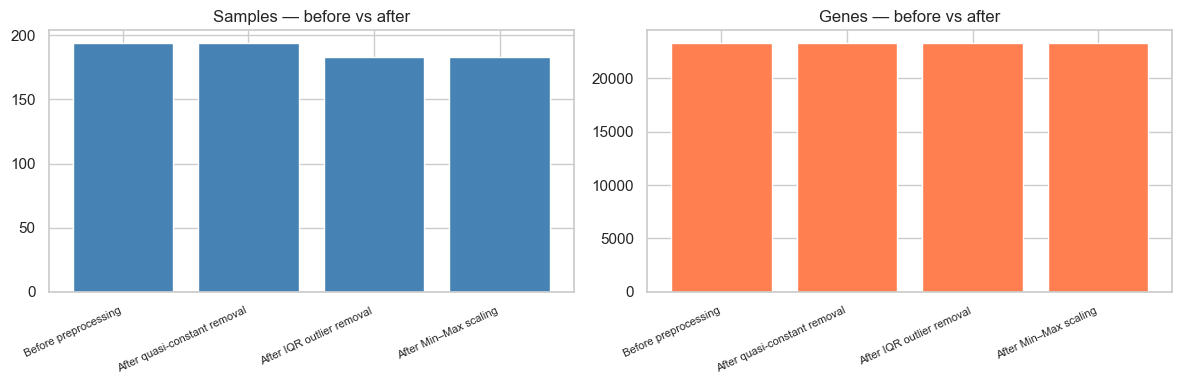

,Stage,Note,n_samples,n_genes,min,max,mean,std
0,Before preprocessing,,194,23307,2.173557,14.329309,6.899199,1.772604
1,After quasi-constant removal,removed 4 genes (variance <= 0.01),194,23303,2.173557,14.329309,6.898586,1.771519
2,After IQR outlier removal,removed 11 samples,183,23303,2.173557,14.329309,6.896169,1.773989
3,After Min–Max scaling,"values scaled to [0, 1]",183,23303,0.000000,1.000001,0.469714,0.209538


'Quasi-constant genes removed: 4'

['BRD7P3', 'RN7SKP9', 'RNA28S5', 'UBC']

'IQR outlier samples removed: 11'

,row_index,label,binary_class,row_mean_expression,iqr_lower,iqr_upper
0,41,IBD,1,6.926858,6.870719,6.922538
1,84,IBD,1,6.925909,6.870719,6.922538
2,85,IBD,1,6.936331,6.870719,6.922538
3,90,IBD,1,6.975135,6.870719,6.922538
4,94,IBD,1,6.931554,6.870719,6.922538
5,97,IBD,1,6.974483,6.870719,6.922538
6,141,IBD,1,6.934261,6.870719,6.922538
7,157,IBD,1,6.932345,6.870719,6.922538
8,172,IBD,1,6.934514,6.870719,6.922538
9,184,Healthy,0,6.926588,6.870719,6.922538


'Quasi-constant genes removed: 4'

['BRD7P3', 'RN7SKP9', 'RNA28S5', 'UBC']

'IQR outlier samples removed: 11'

,row_index,label,binary_class,row_mean_expression,iqr_lower,iqr_upper
0,41,IBD,1,6.926858,6.870719,6.922538
1,84,IBD,1,6.925909,6.870719,6.922538
2,85,IBD,1,6.936331,6.870719,6.922538
3,90,IBD,1,6.975135,6.870719,6.922538
4,94,IBD,1,6.931554,6.870719,6.922538
5,97,IBD,1,6.974483,6.870719,6.922538
6,141,IBD,1,6.934261,6.870719,6.922538
7,157,IBD,1,6.932345,6.870719,6.922538
8,172,IBD,1,6.934514,6.870719,6.922538
9,184,Healthy,0,6.926588,6.870719,6.922538


In [3]:
print(f"Quasi-constant filter: {config.quasi_constant_method}", end="")
if config.quasi_constant_method == "variance":
    print(f" (threshold <= {config.quasi_constant_variance_threshold})")
else:
    print(f" (frequency >= {config.quasi_constant_frequency_threshold})")
s32_ibd = run_section32_preprocess(X_ibd, y_ibd, labels_ibd, show_plots=config.show_plots, display_fn=display, config=config)
display_preprocessing_removals(s32_ibd, display_fn=display)


### §3.3 DEG Analysis

**What it does:** finds genes differentially expressed between **case** (IBD) and **control** (healthy).

**How it works:** Welch t-test per gene → Benjamini–Hochberg (FDR) → fold-change threshold (paper: **1.06712** in log2 for GSE75214).

**What to check:** significant gene counts (up/down), whether the FC threshold is reasonable, and whether counts match the paper (~hundreds of DEGs).


In [4]:
deg_result = run_section33_deg(X_ibd, y_ibd, labels_ibd, config, display_fn=display, preprocessed=s32_ibd)


,Category,Our_count,Paper_Syed2024,Difference,Difference_pct
0,Upregulated,1371,1422,-51,-3.59
1,Downregulated,756,817,-61,-7.47
2,Total DEG,2127,2239,-112,-5.00


#### Volcano plot

**What it is:** scatter plot summarizing the DEG analysis for all genes.

**Axes:** X = **log2 fold change** (expression up/down); Y = **−log10(p-value)** (significance; higher = more significant).

**Colors:** red = upregulated, blue = downregulated, gray = not significant. Dashed horizontal line ≈ p = 0.05.

**What to check:** genes in the upper corners (large |FC|, low p) are strong candidates; most should sit in the center/gray.


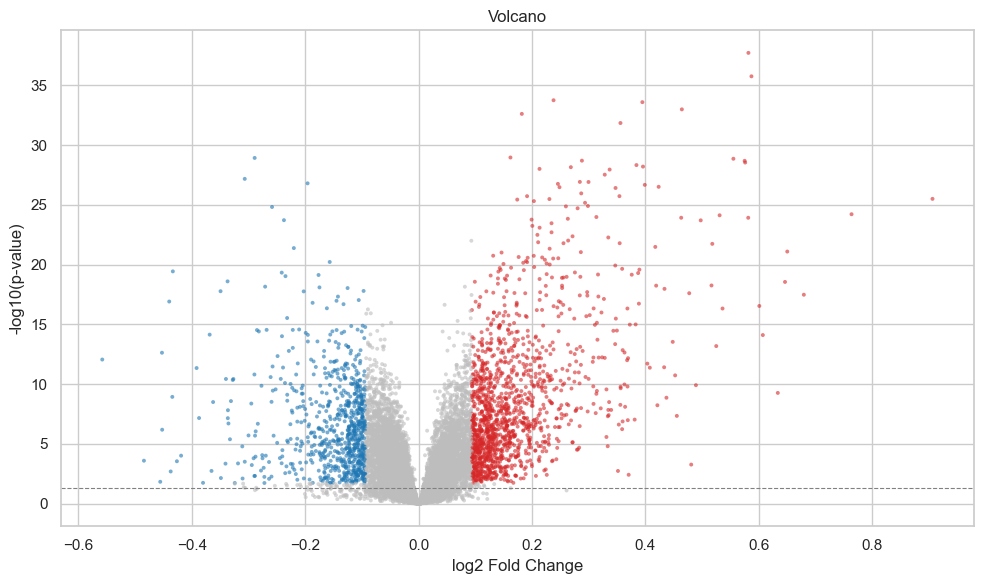

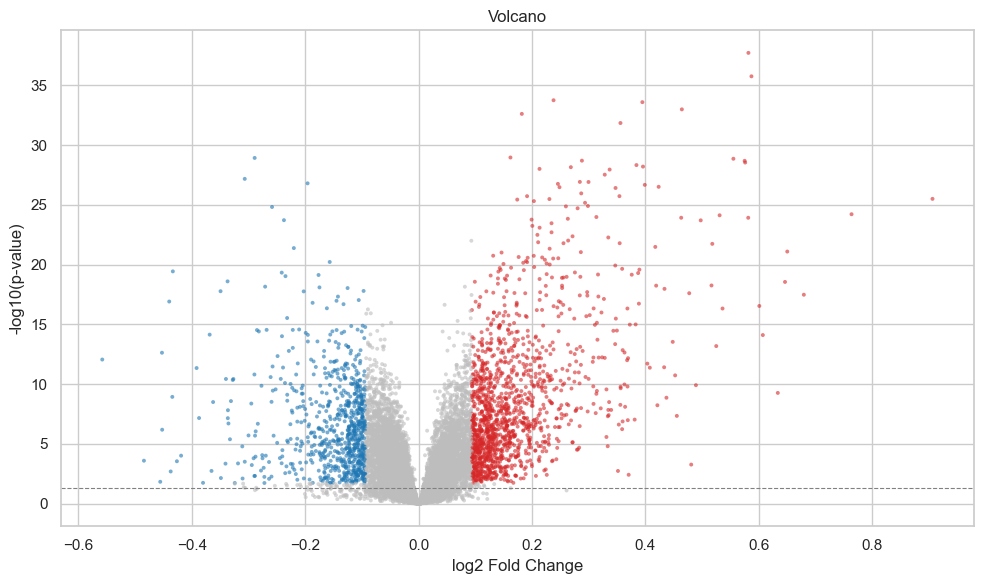

In [5]:
up = deg_result.deg_sig[deg_result.deg_sig["direction"] == "upregulated"]["gene"].tolist()
down = deg_result.deg_sig[deg_result.deg_sig["direction"] == "downregulated"]["gene"].tolist()
plot_volcano(deg_result.deg_table, deg_result.fc_threshold, config.case_label, config.ctrl_label, "Volcano")


#### Heatmap (clustermap) DEG

**What it is:** expression matrix of **top genes** (up and down), with samples clustered by similarity.

**Rows:** genes; **columns:** samples (top bar: red = case, blue = control). Colors = **Z-score** (red = high vs gene mean, blue = low).

**What to check:** coherent color blocks — up genes redder in cases, down genes bluer in cases. Clustering separates sample groups when there is biological signal.


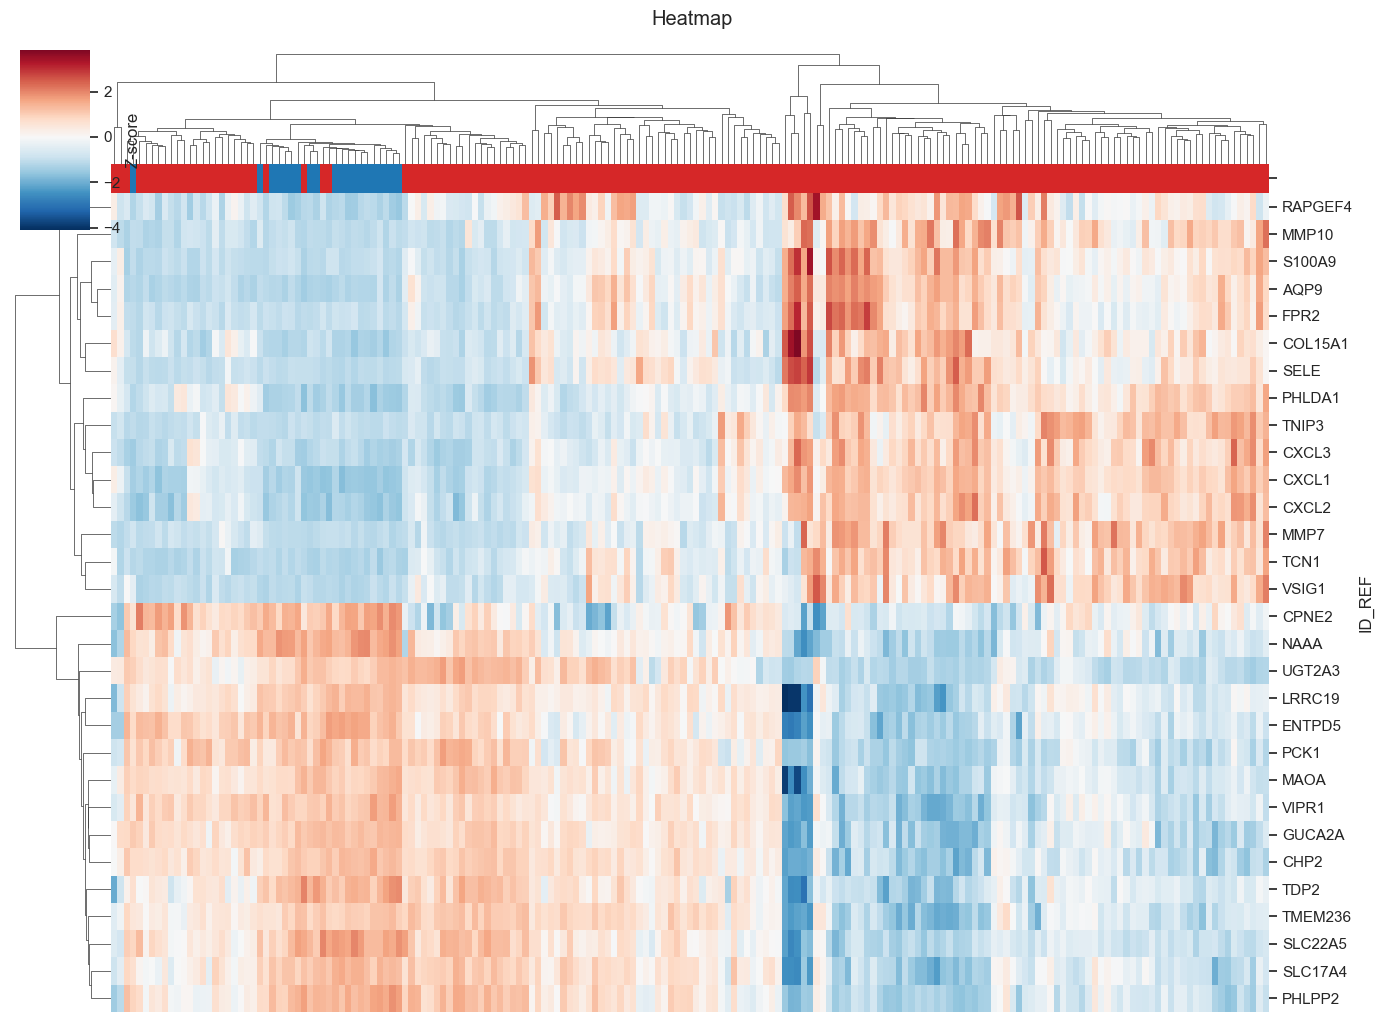

In [6]:
plot_deg_heatmap(deg_result.X_deg, deg_result.y, deg_result.deg_sig, config.case_label, config.ctrl_label, "Heatmap")


#### Venn diagram (up vs down)

**What it shows:** how many genes are **up only**, **down only**, or shared (usually 0 in up∩down).

**What to check:** the two circles should be disjoint (a gene cannot be both up and down). Totals should match the DEG table.


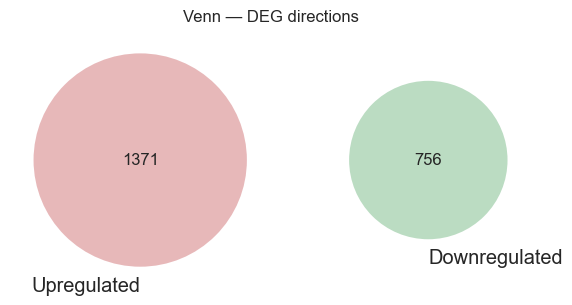

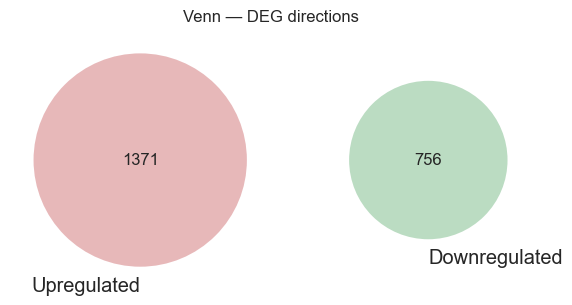

In [7]:
plot_venn(up, down, "Venn — DEG directions")


### §3.6 Train / Test split — BEFORE feature selection

**Anti-leakage:** split on full DEG matrix before §3.4 when `fs_on_train_only=True` (default).


In [8]:
y_ml = deg_result.y.reset_index(drop=True)
labels_ml = deg_result.labels.reset_index(drop=True)
deg_genes = deg_result.deg_sig["gene"].tolist()
X_fs_full = minmax_deg_matrix(deg_result.X_deg, deg_genes)
s36 = run_section36_split(X_fs_full, y_ml, labels_ml, config, display_fn=display)


,Set,Samples,Case,Control
0,Train,118,105,13
1,Test,65,58,7
2,Total,183,163,20


### §3.4.0 Prepare FS context

**What it does:** prepares the matrix with DEG genes only for feature selection (FS).

**How it works:** **MinMax** scale (0–1) on DEGs; FS on **train only** if `fs_on_train_only=True`; **RUS** to balance classes and speed up FS.

**What to check:** `X_fs` dimensions and up/down pool sizes (all DEGs per direction).


In [9]:
if config.fs_on_train_only:
    fs_ctx = run_section34_prepare_on_train(deg_result, s36, config, display_fn=display)
else:
    fs_ctx = run_section34_prepare(deg_result, config)
print(f"FS matrix: {fs_ctx.X_fs.shape} | pools up={len(fs_ctx.up_pool)} down={len(fs_ctx.down_pool)}")


,FS mode,train_samples,test_samples,deg_genes
0,train_only,118,65,2127


FS matrix: (183, 2127) | pools up=300 down=300


### §3.4.1 Filter — Mutual Information (MI)

**What it is:** **filter** method measuring nonlinear dependence between each gene and the label (case/control).

**How it works:** computes MI per gene in the up or down pool; **#1** goes to Table 3, **top-25** to the overlap heatmap.

**What to check:** high-MI genes are most informative for classification; compare up vs down separately.


In [10]:
fs_341 = run_section341_mi(fs_ctx, config)
display({"up": fs_341.up_gene, "down": fs_341.down_gene})


{'up': 'BATF2', 'down': 'RMDN2'}

### §3.4.2 Wrapper — RFECV

**What it is:** **wrapper** that trains a model (Random Forest) and recursively drops less important genes.

**How it works:** RFECV tries different subsets with cross-validation; returns final ranking and #1 per direction.

**What to check:** `n_features_` selected by RFECV; whether #1 matches known paper genes (Table 3).


In [11]:
fs_342 = run_section342_rfecv(fs_ctx, config)
display({"up": fs_342.up_gene, "down": fs_342.down_gene, "n_features_up": fs_342.extra.get("up", {}).get("n_features_")})


{'up': 'PGC', 'down': 'C11orf54', 'n_features_up': np.int64(12)}

### §3.4.3 Embedded — Elastic Net + Gradient Boosting

**What it is:** **embedded** methods that select genes during model training.

- **Elastic Net:** L1+L2 penalized regression → many coefficients = 0 (automatic selection).
- **GBC (Gradient Boosting):** importance from accumulated trees.

**What to check:** Elastic Net usually picks **few** genes (coef ≠ 0); GBC tends to give longer lists. Compare #1 from each with paper Table 3.


In [12]:
fs_343 = run_section343_embedded(fs_ctx, config)
for r in fs_343:
    print(r.method, "->", r.up_gene, r.down_gene)


Elastic Net -> ADAM12 HOOK1
Gradient Boosting Classifier -> CXCL2 IHH


### §3.4.4 Feature Complementation — Table 3 + overlap + master biomarkers

**What it does (paper §3.4.4):** after running 4 FS methods separately on **up** and **down** pools, results are **complemented** — not just one method, but the union and consensus across methods.

**Two distinct sets (important):**

| Set | Contents | Use |
|----------|--------------|-----|
| **Table 3** (`table3_master`) | **#1** from each method × 4 methods × 2 directions ≈ **8 genes** | Compare with paper Table 3; ML §3.5–§3.10 |
| **Overlap union** (`master_biomarkers`) | Union of **top-25** from each method (~100–150 genes) | Exploration, consensus, plots |

**Table 3 — columns**
- `Selected Upregulated` / `Selected Downregulated` → #1 gene per method
- `N_up` / `N_down` → how many genes that method ranked (25 for MI/RFECV/GBC; Elastic Net usually fewer)

**Overlap heatmap (2 panels: UP and DOWN)**
- **Left panel (blue):** rows = genes in the union; columns = MI, RFECV, Elastic Net, GBC. Blue square = that method included the gene in its top-25.
- **Right panel (red, Total/votes):** how many methods agreed (1–4). **Total = 4** → maximum consensus; **Total = 1** → only one method selected it.

**Master merged table:** each gene with `method_votes`, `methods` (which methods selected it), `log2FC`, `qvalue`.

**What to check:**
1. Table 3 vs paper (ARNTL2, COL6A1, TNIP3, CYYR1 / STRADB, PLXNA2, SLC26A2, PTPRF)
2. Genes with **votes ≥ 2** — more robust biomarkers
3. Vote distribution (many genes with 1 vote vs few with 3–4?)
4. Elastic Net with few genes — normal (L1 sparse)


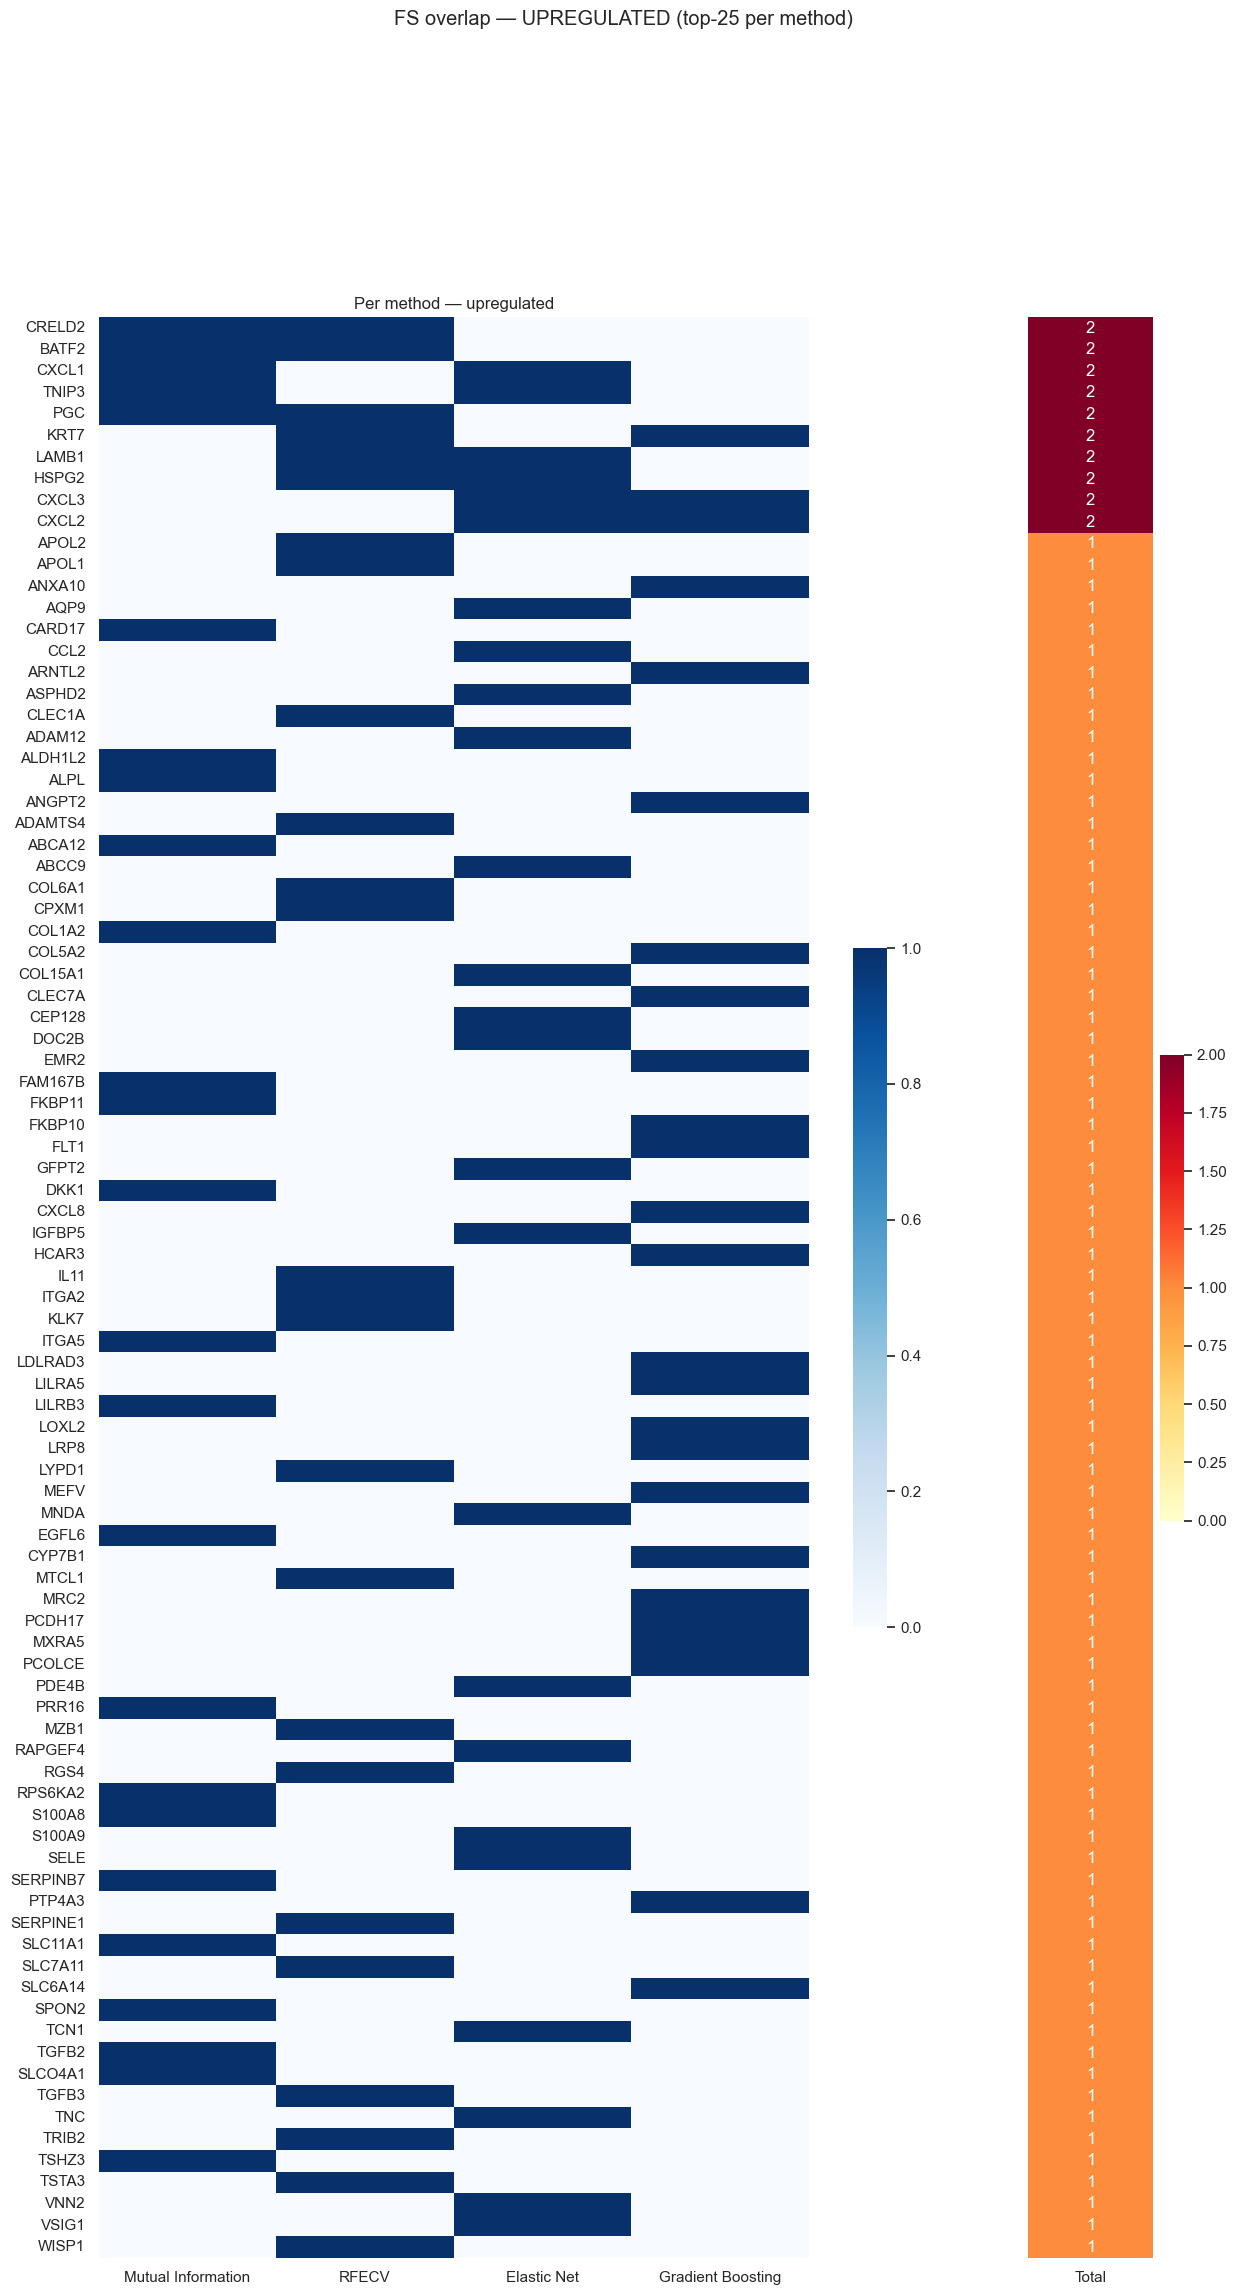

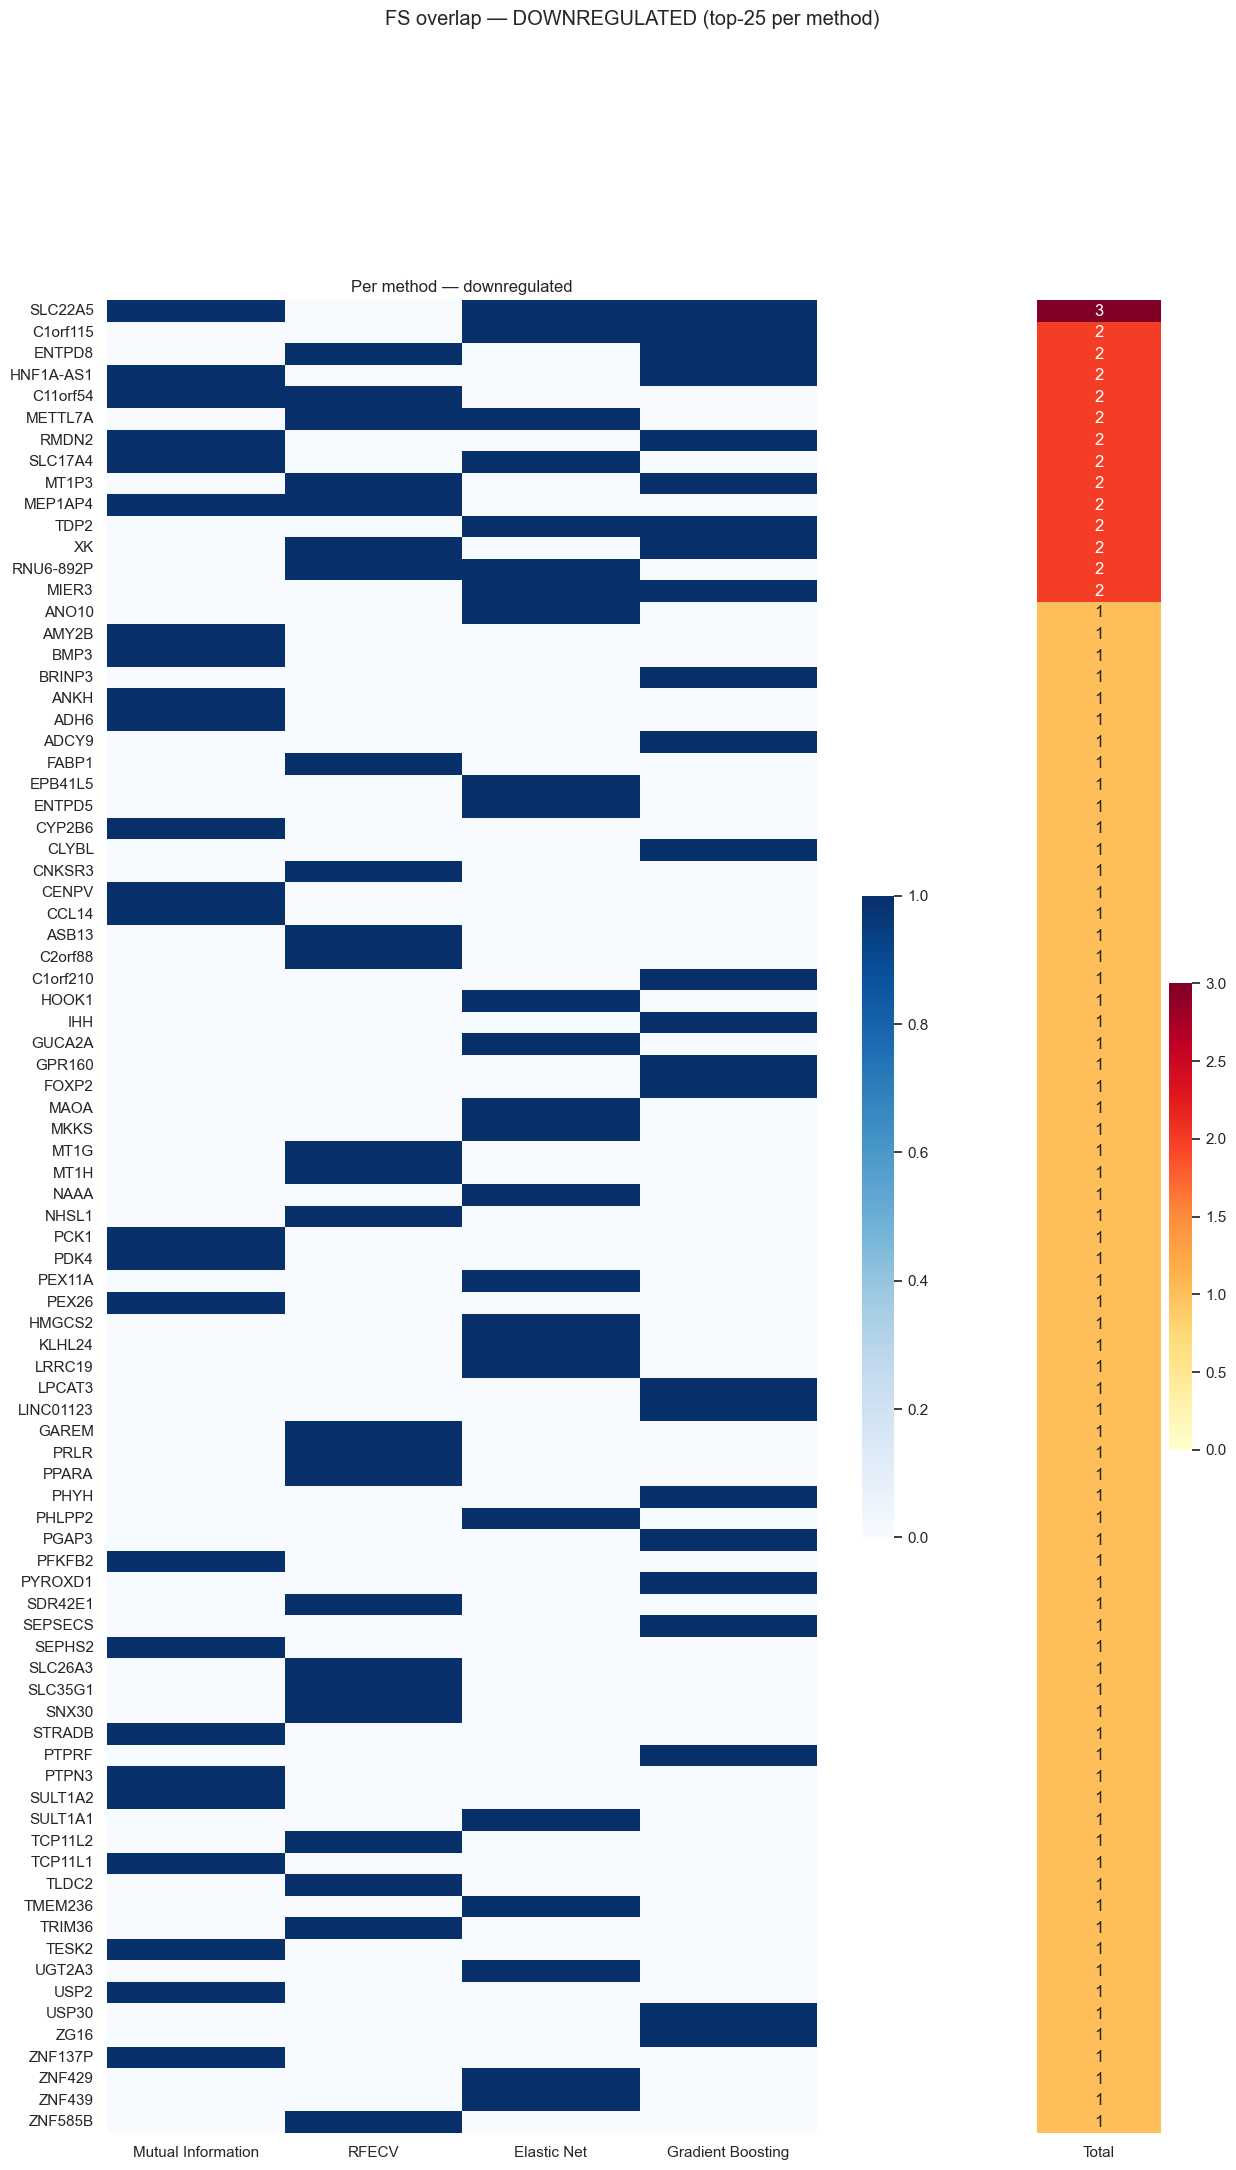

,FS Methods,Type of FS Method,Selected Upregulated,Selected Downregulated,N_up,N_down
0,Mutual Information Score,Filter,BATF2,RMDN2,25,25
1,RFECV,Wrapper,PGC,C11orf54,25,25
2,Elastic Net,Embedded,ADAM12,HOOK1,25,25
3,Gradient Boosting Classifier,Embedded,CXCL2,IHH,25,25


,table3_master (#1 each method)
0,ADAM12
1,BATF2
2,C11orf54
3,CXCL2
4,HOOK1
5,IHH
6,PGC
7,RMDN2



Union of all top-25 lists: 175 genes (UP=90, DOWN=85)

--- UPREGULATED: vote distribution (methods agreeing) ---


,votes,n_genes
0,2,10
1,1,80


Top consensus genes (UPREGULATED, votes >= 2):


...

,method,n_up,n_down,top5_up,top5_down
0,Gradient Boosting Classifier,25,25,"CXCL2, CXCL3, LDLRAD3, FLT1, CXCL8","IHH, XK, ENTPD8, SEPSECS, MIER3"



Master merged — UPREGULATED (sorted by method_votes, log2FC, qvalue):


,gene,method_votes,methods,log2FC,qvalue
0,CXCL1,2,"Elastic Net, Mutual Information Score",0.394472,1.465148e-30
1,CXCL3,2,"Elastic Net, Gradient Boosting Classifier",0.181955,9.318953e-30
2,CXCL2,2,"Elastic Net, Gradient Boosting Classifier",0.355835,4.644962e-29
3,TNIP3,2,"Elastic Net, Mutual Information Score",0.554945,3.186833e-26
4,KRT7,2,"Gradient Boosting Classifier, RFECV",0.157494,2.693794e-13
...,...,...,...,...,...
85,ANGPT2,1,Gradient Boosting Classifier,0.206993,4.094142e-11
86,DKK1,1,Mutual Information Score,0.210844,4.152380e-11
87,CARD17,1,Mutual Information Score,0.106699,5.127769e-11
88,FAM167B,1,Mutual Information Score,0.096902,8.044399e-11



Master merged — DOWNREGULATED (sorted by method_votes, log2FC, qvalue):


,gene,method_votes,methods,log2FC,qvalue
0,SLC22A5,3,"Elastic Net, Gradient Boosting Classifier, Mut...",-0.241280,1.130929e-17
1,SLC17A4,2,"Elastic Net, Mutual Information Score",-0.306489,7.668751e-25
2,TDP2,2,"Elastic Net, Gradient Boosting Classifier",-0.156706,1.767330e-18
3,RMDN2,2,"Gradient Boosting Classifier, Mutual Informati...",-0.228742,1.087277e-11
4,HNF1A-AS1,2,"Gradient Boosting Classifier, Mutual Informati...",-0.215822,6.511533e-10
...,...,...,...,...,...
80,HMGCS2,1,Elastic Net,-0.387015,1.040990e-06
81,PFKFB2,1,Mutual Information Score,-0.100247,1.107862e-06
82,ZNF137P,1,Mutual Information Score,-0.110403,1.125065e-06
83,AMY2B,1,Mutual Information Score,-0.147919,1.293887e-06


In [13]:
fs_344 = run_section344_complement(fs_ctx, [fs_341, fs_342] + fs_343, config, display_fn=display)


#### §3.4.4 — Key variables summary

After running the cell above, use these variables in the following sections:


In [14]:
table3 = fs_344.table3
table3_master = fs_344.table3_master
master = fs_344.master_biomarkers
overlap_up = fs_344.overlap_up
overlap_down = fs_344.overlap_down
merged_up = fs_344.master_merged_up
merged_down = fs_344.master_merged_down

print("=" * 60)
print("TABLE 3 — #1 per method (paper Table 3 style)")
print("=" * 60)
display(table3[["FS Methods", "Type of FS Method",
                "Selected Upregulated", "Selected Downregulated", "N_up", "N_down"]])

print(f"\ntable3_master ({len(table3_master)} genes — used in ML §3.5+):")
print(table3_master)

print(f"\nOverlap union ({len(master)} genes — exploration / screening):")
print(f"  UP pool:   {len(merged_up)} genes")
print(f"  DOWN pool: {len(merged_down)} genes")


TABLE 3 — #1 per method (paper Table 3 style)


,FS Methods,Type of FS Method,Selected Upregulated,Selected Downregulated,N_up,N_down
0,Mutual Information Score,Filter,BATF2,RMDN2,25,25
1,RFECV,Wrapper,PGC,C11orf54,25,25
2,Elastic Net,Embedded,ADAM12,HOOK1,25,25
3,Gradient Boosting Classifier,Embedded,CXCL2,IHH,25,25



table3_master (8 genes — used in ML §3.5+):
['ADAM12', 'BATF2', 'C11orf54', 'CXCL2', 'HOOK1', 'IHH', 'PGC', 'RMDN2']

Overlap union (175 genes — exploration / screening):
  UP pool:   90 genes
  DOWN pool: 85 genes


#### §3.4.4 — Per-method gene lists (top FS genes)

Each row shows how many genes the method selected and the **top 5** in each direction.


In [15]:
method_rows = []
for method_name, picks in fs_344.detail.items():
    up_list = list(picks["upregulated"])
    down_list = list(picks["downregulated"])
    method_rows.append({
        "Method": method_name,
        "N_up": len(up_list),
        "N_down": len(down_list),
        "Top5_up": ", ".join(up_list[:5]),
        "Top5_down": ", ".join(down_list[:5]),
        "All_up": ", ".join(up_list),
        "All_down": ", ".join(down_list),
    })
display(pd.DataFrame(method_rows))


,Method,N_up,N_down,Top5_up,Top5_down,All_up,All_down
0,Mutual Information Score,25,25,"BATF2, CRELD2, CARD17, EGFL6, FAM167B","RMDN2, TESK2, AMY2B, PDK4, PEX26","BATF2, CRELD2, CARD17, EGFL6, FAM167B, ABCA12,...","RMDN2, TESK2, AMY2B, PDK4, PEX26, ZNF137P, MEP..."
1,RFECV,25,25,"PGC, LYPD1, HSPG2, MTCL1, CRELD2","C11orf54, SNX30, RNU6-892P, C2orf88, FABP1","PGC, LYPD1, HSPG2, MTCL1, CRELD2, KLK7, BATF2,...","C11orf54, SNX30, RNU6-892P, C2orf88, FABP1, MT..."
2,Elastic Net,25,25,"ADAM12, TCN1, AQP9, COL15A1, CXCL1","HOOK1, GUCA2A, SLC17A4, NAAA, PHLPP2","ADAM12, TCN1, AQP9, COL15A1, CXCL1, SELE, CXCL...","HOOK1, GUCA2A, SLC17A4, NAAA, PHLPP2, LRRC19, ..."
3,Gradient Boosting Classifier,25,25,"CXCL2, CXCL3, LDLRAD3, FLT1, CXCL8","IHH, XK, ENTPD8, SEPSECS, MIER3","CXCL2, CXCL3, LDLRAD3, FLT1, CXCL8, HCAR3, LIL...","IHH, XK, ENTPD8, SEPSECS, MIER3, C1orf115, CLY..."


#### §3.4.4 — Cross-method consensus (overlap tables)

Genes sorted by **votes** (Total). Top rows were selected by more methods.


In [16]:
vote_col = "votes" if "votes" in overlap_up.columns else "Total"

print("--- UPREGULATED: highest-vote genes ---")
display(overlap_up.sort_values(vote_col, ascending=False).head(25))

print("\n--- DOWNREGULATED: highest-vote genes ---")
display(overlap_down.sort_values(vote_col, ascending=False).head(25))

print("\n--- Consensus genes (votes >= 2) ---")
consensus_up = overlap_up[overlap_up[vote_col] >= 2]
consensus_down = overlap_down[overlap_down[vote_col] >= 2]
print(f"UP:   {len(consensus_up)} genes")
print(f"DOWN: {len(consensus_down)} genes")
if len(consensus_up):
    display(consensus_up)
if len(consensus_down):
    display(consensus_down)
screened = screened_consensus_genes(overlap_up, overlap_down, min_votes=2)
print(f"\nScreened biomarkers (votes>=2): {len(screened)} genes")


--- UPREGULATED: highest-vote genes ---


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
CRELD2,1,1,0,0,2
BATF2,1,1,0,0,2
CXCL1,1,0,1,0,2
TNIP3,1,0,1,0,2
PGC,1,1,0,0,2
KRT7,0,1,0,1,2
LAMB1,0,1,1,0,2
HSPG2,0,1,1,0,2
CXCL3,0,0,1,1,2
CXCL2,0,0,1,1,2



--- DOWNREGULATED: highest-vote genes ---


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
SLC22A5,1,0,1,1,3
C1orf115,0,0,1,1,2
ENTPD8,0,1,0,1,2
HNF1A-AS1,1,0,0,1,2
C11orf54,1,1,0,0,2
METTL7A,0,1,1,0,2
RMDN2,1,0,0,1,2
SLC17A4,1,0,1,0,2
MT1P3,0,1,0,1,2
MEP1AP4,1,1,0,0,2



--- Consensus genes (votes >= 2) ---
UP:   10 genes
DOWN: 14 genes


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
CRELD2,1,1,0,0,2
BATF2,1,1,0,0,2
CXCL1,1,0,1,0,2
TNIP3,1,0,1,0,2
PGC,1,1,0,0,2
KRT7,0,1,0,1,2
LAMB1,0,1,1,0,2
HSPG2,0,1,1,0,2
CXCL3,0,0,1,1,2
CXCL2,0,0,1,1,2


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
SLC22A5,1,0,1,1,3
C1orf115,0,0,1,1,2
ENTPD8,0,1,0,1,2
HNF1A-AS1,1,0,0,1,2
C11orf54,1,1,0,0,2
METTL7A,0,1,1,0,2
RMDN2,1,0,0,1,2
SLC17A4,1,0,1,0,2
MT1P3,0,1,0,1,2
MEP1AP4,1,1,0,0,2



Screened biomarkers (votes>=2): 24 genes


#### §3.4.4 — HFCP screened biomarkers (consensus)

Validation plots for genes with **votes >= 2** (broader than Table 3).


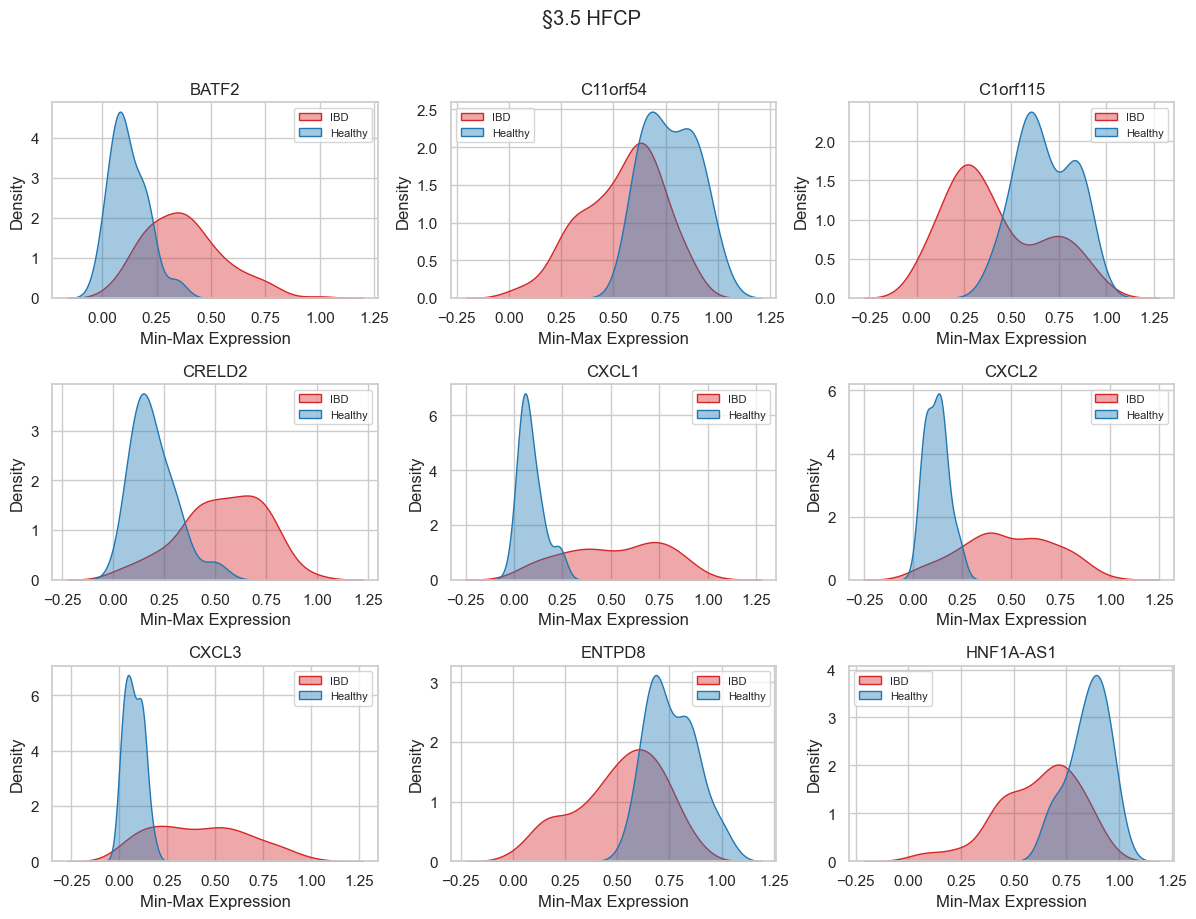

,Gene Biomarker,Direction,Case Mean,Control Mean,t-Statistic,p-Value
0,BATF2,upregulated,0.375436,0.121536,10.822493,3.401935e-14
1,C11orf54,downregulated,0.540790,0.772736,-7.312987,2.971661e-08
2,C1orf115,downregulated,0.413456,0.678706,-6.878339,5.088865e-08
3,CRELD2,upregulated,0.536558,0.199363,11.569330,3.607537e-14
4,CXCL1,upregulated,0.518564,0.087722,17.633773,2.514609e-34
5,CXCL2,upregulated,0.483928,0.118124,16.513158,1.395178e-32
6,CXCL3,upregulated,0.420371,0.076132,15.439055,2.399989e-33
7,ENTPD8,downregulated,0.510314,0.761016,-8.253809,6.380222e-10
8,HNF1A-AS1,downregulated,0.615624,0.853440,-9.087810,1.553585e-11


In [17]:
if screened:
    s35_screened = run_section35_hfcp(fs_ctx.X_fs, deg_result.y, screened, deg_result.deg_table, config, display_fn=display)


#### §3.4.4 — Master merged (expression + votes)

Full table with DEG statistics and which methods selected each gene.


In [18]:
print(f"Master merged UP ({len(merged_up)} genes):")
display(merged_up)

print(f"\nMaster merged DOWN ({len(merged_down)} genes):")
display(merged_down)


Master merged UP (90 genes):


,gene,method_votes,methods,log2FC,qvalue
0,CXCL1,2,"Elastic Net, Mutual Information Score",0.394472,1.465148e-30
1,CXCL3,2,"Elastic Net, Gradient Boosting Classifier",0.181955,9.318953e-30
2,CXCL2,2,"Elastic Net, Gradient Boosting Classifier",0.355835,4.644962e-29
3,TNIP3,2,"Elastic Net, Mutual Information Score",0.554945,3.186833e-26
4,KRT7,2,"Gradient Boosting Classifier, RFECV",0.157494,2.693794e-13
...,...,...,...,...,...
85,ANGPT2,1,Gradient Boosting Classifier,0.206993,4.094142e-11
86,DKK1,1,Mutual Information Score,0.210844,4.152380e-11
87,CARD17,1,Mutual Information Score,0.106699,5.127769e-11
88,FAM167B,1,Mutual Information Score,0.096902,8.044399e-11



Master merged DOWN (85 genes):


,gene,method_votes,methods,log2FC,qvalue
0,SLC22A5,3,"Elastic Net, Gradient Boosting Classifier, Mut...",-0.241280,1.130929e-17
1,SLC17A4,2,"Elastic Net, Mutual Information Score",-0.306489,7.668751e-25
2,TDP2,2,"Elastic Net, Gradient Boosting Classifier",-0.156706,1.767330e-18
3,RMDN2,2,"Gradient Boosting Classifier, Mutual Informati...",-0.228742,1.087277e-11
4,HNF1A-AS1,2,"Gradient Boosting Classifier, Mutual Informati...",-0.215822,6.511533e-10
...,...,...,...,...,...
80,HMGCS2,1,Elastic Net,-0.387015,1.040990e-06
81,PFKFB2,1,Mutual Information Score,-0.100247,1.107862e-06
82,ZNF137P,1,Mutual Information Score,-0.110403,1.125065e-06
83,AMY2B,1,Mutual Information Score,-0.147919,1.293887e-06


### §3.5 HFCP — Histogram / Frequency / Comparative Plot

**What it is:** expression distribution of each Table 3 biomarker comparing **case vs control**.

**How it works:** density curves (KDE) on MinMax expression; red = IBD, blue = control. The t-test table confirms statistical significance.

**What to check:** **separated** curves = good biomarker; **overlapping** curves = weak discrimination. Check p-value and direction (up/down) in the table.


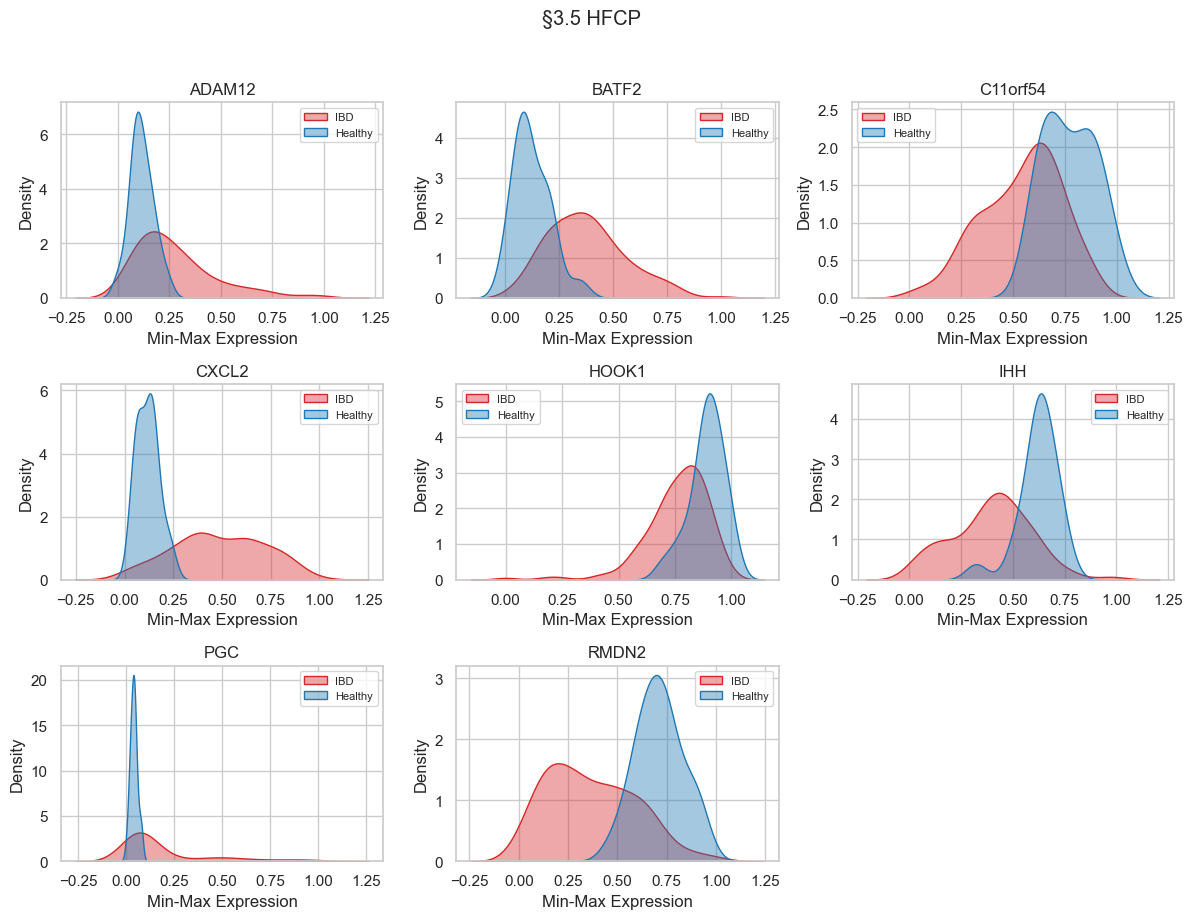

,Gene Biomarker,Direction,Case Mean,Control Mean,t-Statistic,p-Value
0,ADAM12,upregulated,0.277179,0.114325,8.125769,1.495403e-12
1,BATF2,upregulated,0.375436,0.121536,10.822493,3.401935e-14
2,C11orf54,downregulated,0.540790,0.772736,-7.312987,2.971661e-08
3,CXCL2,upregulated,0.483928,0.118124,16.513158,1.395178e-32
4,HOOK1,downregulated,0.758183,0.889588,-6.456787,1.359489e-07
5,IHH,downregulated,0.396764,0.620445,-8.581148,9.196657e-11
6,PGC,upregulated,0.193995,0.039719,7.900011,3.001715e-13
7,RMDN2,downregulated,0.366604,0.712002,-10.976473,1.638926e-13


In [19]:
s35 = run_section35_hfcp(fs_ctx.X_fs, deg_result.y, table3_master, deg_result.deg_table, config, display_fn=display)


### §3.6b ML feature matrix (Table 3 genes from split)


In [20]:
s36_ml = slice_section36_genes(s36, table3_master)


### §3.7 Balance training set (Paper: SMOTE | Exam: RUS)

**What it does:** corrects **class imbalance** on the training set only.

- **SMOTE (paper):** creates synthetic samples for the minority class.
- **RUS (exam):** randomly undersamples the majority class to match.

**Two training sets** (for §3.8–§3.10 comparison):

| Set | Source |
|-----|--------|
| `train_unbal` | Original train after split (unbalanced) |
| `train_smote` | SMOTE-balanced train 50/50 (paper) |

**What to check:** before/after counts — classes 50/50 after balancing. **Never** balance the test set.


In [21]:
s37 = run_section37_balance(s36_ml.X_train, s36_ml.y_train, config, return_both=True, display_fn=display)
train_unbal = (s37.train_unbalanced.X_train, s37.train_unbalanced.y_train)
train_smote = (s37.train_balanced.X_train, s37.train_balanced.y_train)
print("Method:", s37.method)
print("Unbalanced train:", pd.Series(train_unbal[1]).value_counts().to_dict())
print("SMOTE train:", pd.Series(train_smote[1]).value_counts().to_dict())


,before,after,method
0,"{1: 105, 0: 13}","{1: 105, 0: 105}",smote


Method: smote
Unbalanced train: {1: 105, 0: 13}
SMOTE train: {1: 105, 0: 105}


### §3.8 LOOCV — Leave-One-Out Cross-Validation

**What it is:** cross-validation where each sample is held out **once** while training on the rest (N−1).

**Confusion matrix — cell meanings**

Here: **control = 0** (healthy), **case/IBD = 1** (disease).  
Rows = **actual**; columns = **predicted**:

|  | Predicted control (0) | Predicted case (1) |
|--|----------------------|-------------------|
| **Actual control (0)** | **TN** — correct | **FP** — false positive |
| **Actual case (1)** | **FN** — false negative | **TP** — correct |

- **TN (True Negative):** healthy, predicted healthy.
- **TP (True Positive):** diseased, predicted diseased.
- **FP (False Positive):** healthy but predicted diseased. Clinically costly false alarm.
- **FN (False Negative):** diseased but predicted healthy. Missed disease — serious in diagnosis.

**Accuracy** = (TP + TN) / (TP + TN + FP + FN) — fraction of correct predictions.

**What to check:** LOOCV accuracy per model; **low FP and FN** is better. Run **twice**: with `train_unbal` (real imbalance) and `train_smote` (synthetic). Compare models (final evaluation is §3.10).


In [22]:
print("--- LOOCV: train unbalanced ---")
s38_unbal = run_section38_loocv(*train_unbal, table3_master, config, display_fn=display, train_label="unbalanced")
print("--- LOOCV: train SMOTE (paper) ---")
s38_smote = run_section38_loocv(*train_smote, table3_master, config, display_fn=display, train_label="smote")


--- LOOCV: train unbalanced ---


,LOOCV train,CM check
0,"Healthy=13, IBD=105, total=118 (unbalanced)","TN+FP=13, FN+TP=105 (sumas por fila = train, n..."


,Model,LOOCV Accuracy,TN,FP,FN,TP
7,XGBoost,0.9407,9,4,3,102
5,Random Forest,0.9407,9,4,3,102
1,KNN,0.9237,9,4,5,100
4,Decision Tree,0.9237,7,6,3,102
3,SVC,0.8983,12,1,11,94
2,Gaussian NB,0.8898,11,2,11,94
6,MLP,0.8898,0,13,0,105
0,Logistic Regression,0.8644,13,0,16,89


--- LOOCV: train SMOTE (paper) ---


,LOOCV train,CM check
0,"Healthy=105, IBD=105, total=210 (smote)","TN+FP=105, FN+TP=105 (sumas por fila = train, ..."


,Model,LOOCV Accuracy,TN,FP,FN,TP
7,XGBoost,0.9714,104,1,5,100
5,Random Forest,0.9714,105,0,6,99
4,Decision Tree,0.9619,102,3,5,100
3,SVC,0.9524,105,0,10,95
2,Gaussian NB,0.9524,102,3,7,98
1,KNN,0.9476,105,0,11,94
6,MLP,0.9381,105,0,13,92
0,Logistic Regression,0.9286,105,0,15,90


### §3.9 Train supervised classifiers

**What it does:** trains 7–8 classifiers (LR, KNN, NB, SVC, DT, RF, MLP, XGBoost) on the 8 Table 3 genes.

**What to check:** all models train without error on **both** train sets; fitting only here — real evaluation is §3.10 on test (same unbalanced test for both branches).


In [23]:
s39_unbal = run_section39_train(*train_unbal, table3_master, config)
s39_smote = run_section39_train(*train_smote, table3_master, config)
print("Models trained (unbalanced):", list(s39_unbal.models.keys()))
print("Models trained (SMOTE):", list(s39_smote.models.keys()))


Models trained (unbalanced): ['Logistic Regression', 'KNN', 'Gaussian NB', 'SVC', 'Decision Tree', 'Random Forest', 'MLP', 'XGBoost']
Models trained (SMOTE): ['Logistic Regression', 'KNN', 'Gaussian NB', 'SVC', 'Decision Tree', 'Random Forest', 'MLP', 'XGBoost']


### §3.10 Test-set evaluation — unbalanced vs SMOTE

**What it is:** final metrics on the **35% test** set the model **never saw** during training or LOOCV. Compare training with **unbalanced** vs **SMOTE** (paper) on the **same unbalanced test**.

| Rama | Train | Test |
|------|-------|------|
| A | `train_unbal` (~105 IBD / 13 Healthy) | `s36.X_test` sin tocar |
| B (paper) | `train_smote` (50/50) | mismo test |

**What to expect:**
- **SMOTE (paper):** better TN/FP balance on Healthy; high accuracy (~0.95) because test is IBD-dominated.
- **Unbalanced:** accuracy may look similar if the model predicts mostly IBD, but **FP/FN on Healthy** (minority) often worsen.

**Results table**

| Column | Meaning |
|---------|-------------|
| **Train balance** | `unbalanced` o `smote` |
| **Test Accuracy** | (TP + TN) / total on test |
| **TN, FP, FN, TP** | Same logic as §3.8 |
| **AUC-ROC** | Area under the ROC curve |

**Plots:** two confusion matrices side by side (best model per branch) + **Δ** table (smote − unbalanced).

**What to check:** **test** accuracy; high **FN** means missed cases; high **FP** means healthy labeled as diseased.


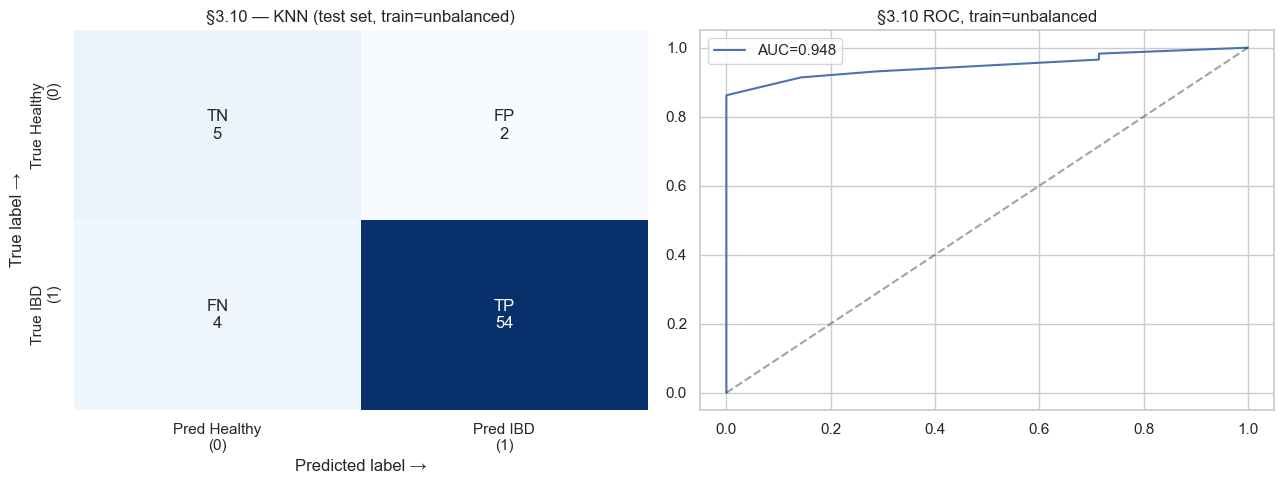

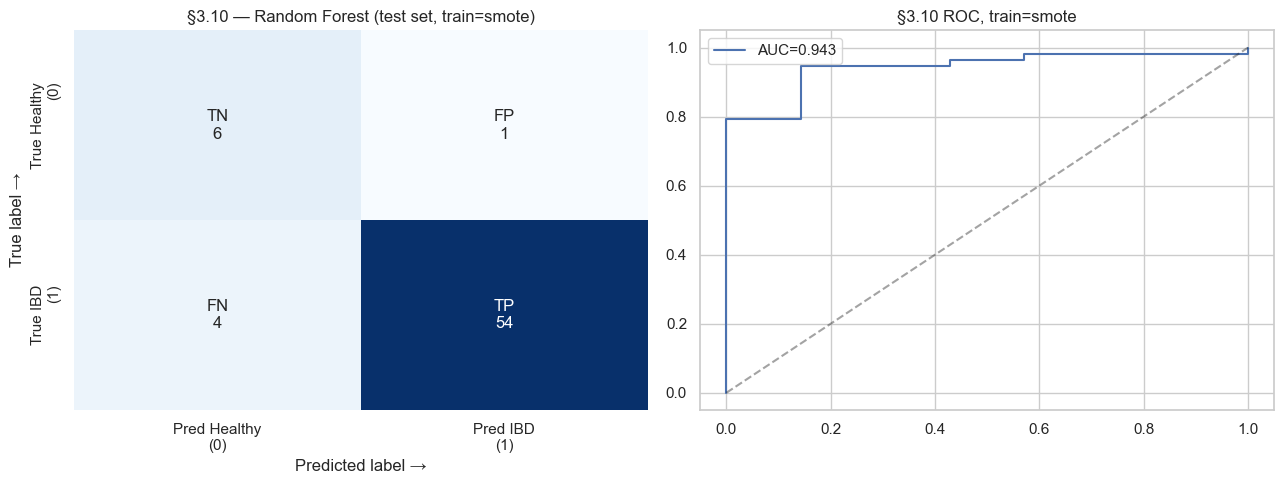

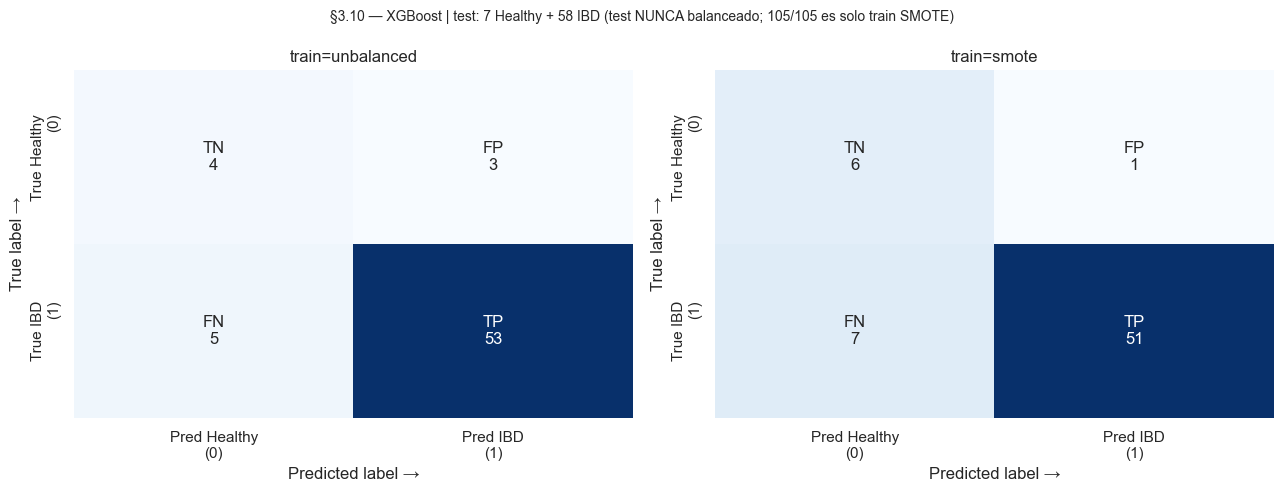

,Set,Healthy,IBD,Total
0,Train (unbalanced),13,105,118
1,Train (smote),105,105,210
2,Test (§3.10 — sin balancear),7,58,65


,LOOCV,Best LOOCV model,Best LOOCV Accuracy
0,unbalanced,XGBoost,0.9407
1,smote,XGBoost,0.9714


,Train balance,Model,Test Accuracy,Balanced Acc,Precision,Recall,Specificity,F1,TN,FP,FN,TP,AUC-ROC
0,unbalanced,KNN,0.9077,0.8227,0.9643,0.9310,0.7143,0.9474,5,2,4,54,0.9483
1,unbalanced,Random Forest,0.9077,0.7599,0.9483,0.9483,0.5714,0.9483,4,3,3,55,0.9532
2,unbalanced,MLP,0.8923,0.5000,0.8923,1.0000,0.0000,0.9431,0,7,0,58,0.9384
3,unbalanced,XGBoost,0.8769,0.7426,0.9464,0.9138,0.5714,0.9298,4,3,5,53,0.9113
4,unbalanced,Gaussian NB,0.8615,0.9224,1.0000,0.8448,1.0000,0.9159,7,0,9,49,0.9655
5,unbalanced,SVC,0.8615,0.9224,1.0000,0.8448,1.0000,0.9159,7,0,9,49,0.9581
6,unbalanced,Decision Tree,0.8462,0.7254,0.9444,0.8793,0.5714,0.9107,4,3,7,51,0.7254
7,unbalanced,Logistic Regression,0.8308,0.9052,1.0000,0.8103,1.0000,0.8952,7,0,11,47,0.9384
8,smote,Random Forest,0.9231,0.8941,0.9818,0.9310,0.8571,0.9558,6,1,4,54,0.9433
9,smote,KNN,0.9077,0.8855,0.9815,0.9138,0.8571,0.9464,6,1,5,53,0.9717


,Model,Δ Test Accuracy (smote−unbalanced),Δ TN (smote−unbalanced),Δ FP (smote−unbalanced),Δ FN (smote−unbalanced),Δ TP (smote−unbalanced),Δ AUC-ROC (smote−unbalanced)
0,KNN,0.0000,1.0,-1.0,1.0,-1.0,0.0234
1,Random Forest,0.0154,2.0,-2.0,1.0,-1.0,-0.0099
2,MLP,-0.0615,7.0,-7.0,11.0,-11.0,-0.0024
3,XGBoost,0.0000,2.0,-2.0,2.0,-2.0,-0.0074
4,Gaussian NB,0.0000,0.0,0.0,0.0,0.0,0.0049
5,SVC,-0.0153,-1.0,1.0,0.0,0.0,-0.0123
6,Decision Tree,0.0153,1.0,-1.0,0.0,0.0,0.0714
7,Logistic Regression,0.0000,0.0,0.0,0.0,0.0,-0.0074


In [24]:
s310_cmp = run_section310_compare(
    *train_unbal, "unbalanced",
    *train_smote, "smote",
    s36_ml.X_test, s36_ml.y_test, table3_master, config,
    display_fn=display, compare_model="XGBoost",
)
s310 = s310_cmp.perf_smote  # paper track — used in §3.11


### §3.11 External validation — GSE10616 + GSE36807

**Mode:** `external_inference_only=True` — **does not train** on external cohorts.

Flow: load GEO → MinMax with GSE75214 reference (`deg_result.X_deg`) → `predict` with `s39_smote.models` → metrics.


In [25]:
config.external_inference_only = True
config.external_use_train_scaler = True
config.data_dir = str(DATA_DIR.resolve())
s311 = run_section311_external(
    table3_master, s39_smote.models, s39_smote.genes, config,
    data_dir=DATA_DIR,
    X_scaler_ref=deg_result.X_deg,
    display_fn=display,
)
if s311.cohort_meta is not None and len(s311.cohort_meta):
    display(s311.cohort_meta)


§3.11 mode: inference_only | scaling: train_reference_minmax | models: ['XGBoost', 'Decision Tree']
GSE10616 | full dim: (58, 16330) (IBD=42, Healthy=16) | eval dim: (30, 6) | biomarkers found: 6/8 | scaling=train_reference
  missing genes: ['C11orf54', 'IHH']


,Test Accuracy,TN,FP,FN,TP,genes_missing_filled_0,AUC-ROC,Model,Cohort,Status,scaling
0,0.6667,15,0,10,5,2,0.6667,XGBoost,GSE10616,ok,train_reference
1,0.5000,0,15,0,15,2,0.5000,Decision Tree,GSE10616,ok,train_reference


GSE36807 | full dim: (35, 23521) (IBD=28, Healthy=7) | eval dim: (22, 8) | biomarkers found: 8/8 | scaling=train_reference


,Test Accuracy,TN,FP,FN,TP,genes_missing_filled_0,AUC-ROC,Model,Cohort,Status,scaling
0,0.4545,7,0,12,3,0,0.4857,XGBoost,GSE36807,ok,train_reference
1,0.6818,0,7,0,15,0,0.5000,Decision Tree,GSE36807,ok,train_reference



--- External validation summary (compare with GSE75214 test) ---
GSE75214 test reference: XGBoost ~0.954 acc | DT ~0.954 acc


,Test Accuracy,TN,FP,FN,TP,genes_missing_filled_0,AUC-ROC,Model,Cohort,Status,scaling
0,0.6667,15,0,10,5,2,0.6667,XGBoost,GSE10616,ok,train_reference
1,0.5000,0,15,0,15,2,0.5000,Decision Tree,GSE10616,ok,train_reference
2,0.4545,7,0,12,3,0,0.4857,XGBoost,GSE36807,ok,train_reference
3,0.6818,0,7,0,15,0,0.5000,Decision Tree,GSE36807,ok,train_reference


,geo_id,mode,scaling,full_shape,eval_shape,n_case_full,n_ctrl_full,n_eval,n_genes_mapped,n_genes_missing,missing_genes,labels_eval
0,GSE10616,inference_only,train_reference,"(58, 16330)","(30, 6)",42,16,30,6,2,"[C11orf54, IHH]","{'IBD': 15, 'Healthy': 15}"
1,GSE36807,inference_only,train_reference,"(35, 23521)","(22, 8)",28,7,22,8,0,[],"{'IBD': 15, 'Healthy': 7}"


### §3.12 Pathway analysis (reference)

**What it is:** biological pathway enrichment (KEGG, GO) using selected genes.

**What to check:** which pathways appear and whether they make biological sense for IBD (inflammation, immunity, etc.).


In [26]:
s312 = run_section312_pathway(table3_master, config, display_fn=display)


,gene,in_master_set
0,VWF,False
1,IL1RL1,False
2,DENND2B,False
3,MMP14,False
4,NAAA,False
5,PANK1,False


'Run WebGestalt 2024 ORA (GO + KEGG) on paper final six genes or your master biomarker set. Significance cutoff p < 0.05.'

### Track A — Supplemental baseline comparison (IBD / GSE75214)

RF + val-tuned threshold on **IBD cohort** feature sets. This is Track A (paper replication), not breast cancer.


Track A — IBD Table 3 genes:
['ADAM12', 'BATF2', 'C11orf54', 'CXCL2', 'HOOK1', 'IHH', 'PGC', 'RMDN2']


,Feature_Set,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_F2,Test_Balanced_Acc,Test_TN,Test_FP,Test_FN,Test_TP,Test_AUC,Test_AUC-ROC,Test_AUC_PR,Test_Threshold,Test_n_features,Train_Recall,optimize_metric
5,DISR,0.9077,0.9062,1.0000,0.1429,0.9508,0.9797,0.5714,1,6,0,58,0.9631,0.9631,0.9958,0.06,4,1.0,accuracy
2,Screened_consensus,0.9077,0.9062,1.0000,0.1429,0.9508,0.9797,0.5714,1,6,0,58,0.9409,0.9409,0.9929,0.04,5,1.0,accuracy
1,Table3_8genes (IBD),0.8923,0.8923,1.0000,0.0000,0.9431,0.9764,0.5000,0,7,0,58,0.9532,0.9532,0.9943,0.06,8,1.0,accuracy
0,Baseline_top_DEGs,0.8923,0.9048,0.9828,0.1429,0.9421,0.9661,0.5628,1,6,1,57,0.9384,0.9384,0.9926,0.05,5,1.0,accuracy
3,Merged,0.8923,0.8923,1.0000,0.0000,0.9431,0.9764,0.5000,0,7,0,58,0.9483,0.9483,0.9937,0.07,8,1.0,accuracy
4,Merged_pruned,0.8923,0.8923,1.0000,0.0000,0.9431,0.9764,0.5000,0,7,0,58,0.9483,0.9483,0.9937,0.07,8,1.0,accuracy


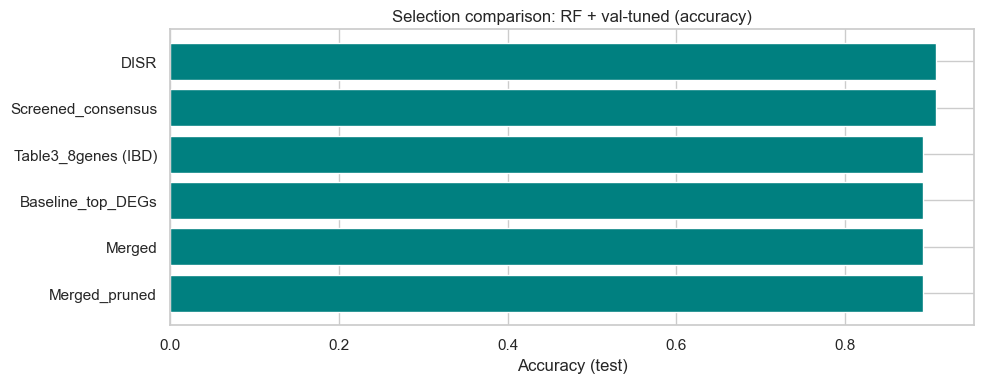

In [27]:
print("Track A — IBD Table 3 genes:")
print(table3_master)
feature_sets_a = build_feature_sets(fs_344, deg_result.deg_sig, config, s36_ml.X_train, s36_ml.y_train)
baseline_cmp_a, _ = run_baseline_suite(
    s36_ml.X_train, s36_ml.y_train, s36_ml.X_test, s36_ml.y_test,
    feature_sets_a, config, display_fn=display,
)


### Full pipeline demo (one call)

In [28]:
# Uncomment to run end-to-end in one call:
# pipeline_result = run_pipeline(X_ibd, y_ibd, labels_ibd, PaperConfig(show_plots=False), display_fn=display)
# display(pipeline_result.summary())


---
## Summary

| Step | Function | Output |
|------|----------|--------|
| §3.3 | `run_section33_deg` | DEG table + counts |
| §3.4 | `run_section34_prepare` + 341/342/343/344 | Table 3 + master biomarkers |
| §3.5–§3.10 | `run_section35_hfcp` … `run_section310_compare` | HFCP, ML metrics (dual train) |
| §3.11 | `run_section311_external` | GSE10616 + GSE36807 (XGBoost, DT) |
| §3.12 | `run_section312_pathway` | pathway notes (reference) |
| All | `run_pipeline(X, y, labels, config)` | `PipelineResult` |

Re-use on breast cancer: `ExamConfig()`, `load_breast_cancer()`, `run_pipeline(...)`.


---
## Question 2 — Track B (Breast Cancer) — Question 1 pipeline

**This section implements exam Question 1** (Figure 1(A) on breast cancer data).  
**Dataset:** `X_data_full.csv` + `y_data_full.csv` | **Config:** `ExamConfig` (RUS, adaptive FC).  
The **Question 2** written answer cell is at the **end** of the notebook.


### 2.1 Load dataset and audit variables

Per paper §3.1–§3.2: load expression matrix and labels, inspect **dimensions**, **dtypes**, and **string labels** before encoding.


In [29]:
exam_config = ExamConfig(show_plots=True)
exam_config.data_dir = str(DATA_DIR.resolve())

y_raw_bc = pd.read_csv(DATA_DIR / "y_data_full.csv", header=None).squeeze("columns")
y_str_bc = y_raw_bc.astype(str).str.strip()
X_raw_bc = pd.read_csv(DATA_DIR / "X_data_full.csv", index_col=0)

print("=== Raw load audit ===")
print(f"X shape (rows=samples, cols=genes): {X_raw_bc.shape}")
print(f"X index (first 5): {list(X_raw_bc.index[:5])}")
print(f"X columns (first 5 genes): {list(X_raw_bc.columns[:5])}")
print(f"X dtypes:\n{X_raw_bc.dtypes.value_counts()}")
print(f"\ny (str) unique values:\n{y_str_bc.value_counts()}")
print(f"\ny (str) head:\n{y_str_bc.head(10).to_string()}")

# Binary encoding: Tumor=1, Normal=0 (paper: categorical → binary)
valid_bc = y_str_bc.isin(["Tumor", "Normal"])
print(f"\nDropped {(~valid_bc).sum()} non-Tumor/Normal rows: {y_str_bc[~valid_bc].unique().tolist()}")
labels_bc = y_str_bc[valid_bc].reset_index(drop=True)
X_bc = X_raw_bc.apply(pd.to_numeric, errors="coerce").astype(np.float32).reset_index(drop=True)
if len(labels_bc) != len(X_bc):
    n = min(len(labels_bc), len(X_bc))
    labels_bc, X_bc = labels_bc.iloc[:n].reset_index(drop=True), X_bc.iloc[:n].reset_index(drop=True)
y_bc = (labels_bc == "Tumor").astype(int)

encoding_bc = pd.DataFrame({
    "label_str": labels_bc.value_counts().index,
    "count": labels_bc.value_counts().values,
    "binary": [1 if x == "Tumor" else 0 for x in labels_bc.value_counts().index],
})
print("\n=== After binary encoding ===")
print(f"Shape: {X_bc.shape}")
display(encoding_bc)
print(f"Class counts: {labels_bc.value_counts().to_dict()}")


=== Raw load audit ===
X shape (rows=samples, cols=genes): (1191, 56936)
X index (first 5): [4474, 3555, 731, 3960, 3834]
X columns (first 5 genes): ['TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR']
X dtypes:
int64    56936
Name: count, dtype: int64

y (str) unique values:
0
Tumor     1080
Normal     111
Sample       1
Name: count, dtype: int64

y (str) head:
0    Sample
1     Tumor
2     Tumor
3     Tumor
4     Tumor
5     Tumor
6     Tumor
7     Tumor
8     Tumor
9     Tumor

Dropped 1 non-Tumor/Normal rows: ['Sample']

=== After binary encoding ===
Shape: (1191, 56936)


,label_str,count,binary
0,Tumor,1080,1
1,Normal,111,0


Class counts: {'Tumor': 1080, 'Normal': 111}


### 2.1b Log₂(x+1) transform — Track B only

**Why Track A does not need this:** GSE75214 (Track A) comes from GEO as **pre-normalized microarray** expression — already on a scale suitable for the Syed pipeline.

**Why Track B needs this:** breast cancer exam data (`X_data_full.csv`) are on a **linear/raw expression scale**. Before §2.2 we apply **log₂(x+1)** to stabilize variance and align with log-scale analyses (DEG fold change, FS).

Applied automatically in §2.2 when `exam_config.use_log2p1 = True` (default for `ExamConfig`).


In [30]:
print("Raw X_bc — min / max / mean:",
      float(X_bc.min().min()), float(X_bc.max().max()), float(np.nanmean(X_bc.values)))
print("exam_config.use_log2p1:", exam_config.use_log2p1)
_preview = np.log2(np.clip(X_bc.values, 0, None) + 1)
print("After log2(x+1) preview — min / max / mean:",
      float(np.nanmin(_preview)), float(np.nanmax(_preview)), float(np.nanmean(_preview)))


Raw X_bc — min / max / mean: 0.0 7683396.0 1017.8466796875
exam_config.use_log2p1: True
After log2(x+1) preview — min / max / mean: 0.0 22.87331199645996 3.522475242614746


### 2.2 Preprocessing (Paper §3.2)

Steps from Syed et al. (2024) §3.2 (Track B):
1. **log₂(x+1)** — linear → log scale (`exam_config.use_log2p1 = True`)
2. **Binary encoding** of categorical labels (done in §2.1)
3. **Remove quasi-constant features** — variance **≤ 0.01** (`exam_config.quasi_constant_method = "variance"`, same as Track A)
4. **IQR outlier removal** on sample row means
5. **Min–Max normalization** to [0, 1]

Table below compares **before vs after** each stage (samples, genes, value range).


Quasi-constant filter: variance (threshold <= 0.01)


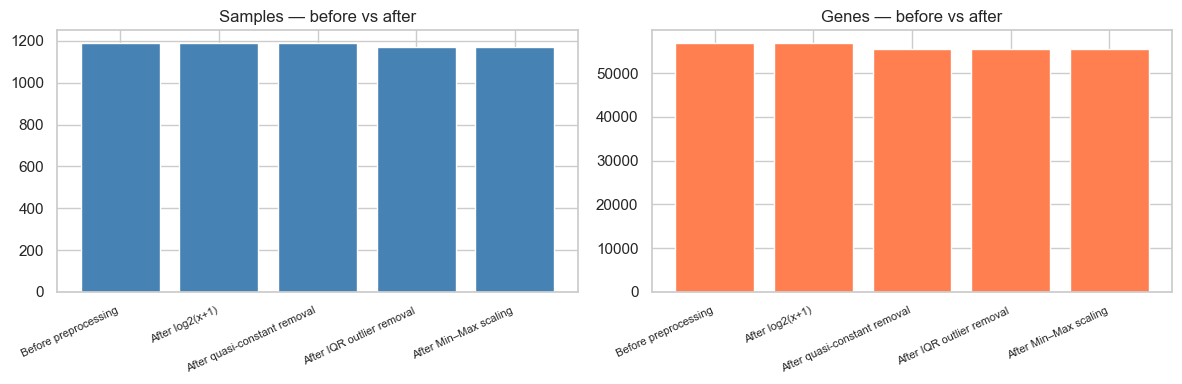

,Stage,Note,n_samples,n_genes,min,max,mean,std
0,Before preprocessing,,1191,56936,0.0,7.683396e+06,1017.846802,9751.962891
1,After log2(x+1),log2(x+1),1191,56936,0.0,2.287331e+01,3.522485,4.372971
2,After quasi-constant removal,removed 1456 genes (variance <= 0.01),1191,55480,0.0,2.287331e+01,3.614822,4.392171
3,After IQR outlier removal,removed 21 samples,1170,55480,0.0,2.274558e+01,3.610543,4.395582
4,After Min–Max scaling,"values scaled to [0, 1]",1170,55480,0.0,1.000000e+00,0.267785,0.270230


'Quasi-constant genes removed: 1456'

['TTTY1',
 'VCY',
 'CDY2B',
 'GDF1',
 'AC027088.1',
 'TTTY7',
 'TTTY7B',
 'TSPY2',
 'RBMY1F',
 'PRY2',
 'TSPY14P',
 'CDY1',
 'CSPG4P4Y',
 'CSPG4P3Y',
 'AC007967.1',
 'AC092634.1',
 'TGIF2LY',
 'DEFB104A',
 'DEFB103A',
 'DEFB104B',
 'OR7E125P',
 'OR4F4',
 'TTTY11',
 'PRORY',
 'TTTY8',
 'PMCH',
 'BPY2',
 'OR4G2P',
 'TTTY13',
 'SSXP4',
 'TTTY8B',
 'BPY2C',
 'DEFB105A',
 'DEFB107A',
 'DEFB106A',
 'DEFB105B',
 'DEFB106B',
 'LCE3B',
 'TSPY13P',
 'DAZ1',
 'ANKRD36P1',
 'DEFB107B',
 'MIR375',
 'MIR1-1',
 'MIR208A',
 'MIR96',
 'AC069285.1',
 'RNU6-896P',
 'RNU6-664P',
 'RNA5SP26']

'... and 1406 more'

'IQR outlier samples removed: 21'

...

['TTTY1',
 'VCY',
 'CDY2B',
 'GDF1',
 'AC027088.1',
 'TTTY7',
 'TTTY7B',
 'TSPY2',
 'RBMY1F',
 'PRY2',
 'TSPY14P',
 'CDY1',
 'CSPG4P4Y',
 'CSPG4P3Y',
 'AC007967.1',
 'AC092634.1',
 'TGIF2LY',
 'DEFB104A',
 'DEFB103A',
 'DEFB104B',
 'OR7E125P',
 'OR4F4',
 'TTTY11',
 'PRORY',
 'TTTY8',
 'PMCH',
 'BPY2',
 'OR4G2P',
 'TTTY13',
 'SSXP4',
 'TTTY8B',
 'BPY2C',
 'DEFB105A',
 'DEFB107A',
 'DEFB106A',
 'DEFB105B',
 'DEFB106B',
 'LCE3B',
 'TSPY13P',
 'DAZ1',
 'ANKRD36P1',
 'DEFB107B',
 'MIR375',
 'MIR1-1',
 'MIR208A',
 'MIR96',
 'AC069285.1',
 'RNU6-896P',
 'RNU6-664P',
 'RNA5SP26']

'... and 1406 more'

'IQR outlier samples removed: 21'

,row_index,label,binary_class,row_mean_expression,iqr_lower,iqr_upper
0,14,Tumor,1,4.913360,2.966563,4.255248
1,18,Tumor,1,2.931356,2.966563,4.255248
2,63,Tumor,1,2.854084,2.966563,4.255248
3,129,Tumor,1,5.036441,2.966563,4.255248
4,259,Tumor,1,2.960750,2.966563,4.255248
5,272,Tumor,1,2.935983,2.966563,4.255248
6,273,Tumor,1,4.846087,2.966563,4.255248
7,425,Tumor,1,4.362605,2.966563,4.255248
8,506,Tumor,1,2.791034,2.966563,4.255248
9,620,Tumor,1,2.901017,2.966563,4.255248



Preprocessing summary:
  quasi_constant_removed: 1456
  outlier_samples_removed: 21
  shape_before: (1191, 56936)
  shape_after: (1170, 55480)
  step_log:                           stage                                   note  \
0          Before preprocessing                                          
1               After log2(x+1)                              log2(x+1)   
2  After quasi-constant removal  removed 1456 genes (variance <= 0.01)   
3     After IQR outlier removal                     removed 21 samples   
4         After Min–Max scaling                values scaled to [0, 1]   

   n_samples  n_features  
0       1191       56936  
1       1191       56936  
2       1191       55480  
3       1170       55480  
4       1170       55480  


In [31]:
print(f"Quasi-constant filter: {exam_config.quasi_constant_method}", end="")
if exam_config.quasi_constant_method == "variance":
    print(f" (threshold <= {exam_config.quasi_constant_variance_threshold})")
else:
    print(f" (frequency >= {exam_config.quasi_constant_frequency_threshold})")
s32_bc = run_section32_preprocess(X_bc, y_bc, labels_bc, show_plots=exam_config.show_plots, display_fn=display, config=exam_config)
display_preprocessing_removals(s32_bc, display_fn=display)
print("\nPreprocessing summary:")
for k, v in s32_bc.prep_info.items():
    if k in ("quasi_constant_removed_genes", "iqr_removed_samples"):
        continue
    print(f"  {k}: {v}")


### §3.3 DEG Analysis — Breast Cancer

Welch t-test per gene → Benjamini–Hochberg FDR → **adaptive** fold-change threshold (exam).  
Uses preprocessed matrix from §2.2 (`s32_bc.X_pp` — quasi-constant + IQR; DEG on expression before MinMax, as in pipeline).


In [32]:
deg_bc = run_section33_deg(X_bc, y_bc, labels_bc, exam_config, display_fn=display, preprocessed=s32_bc)


,Category,Our_count
0,Upregulated,4963
1,Downregulated,3033
2,Total DEG,7996


#### Volcano plot — Breast Cancer


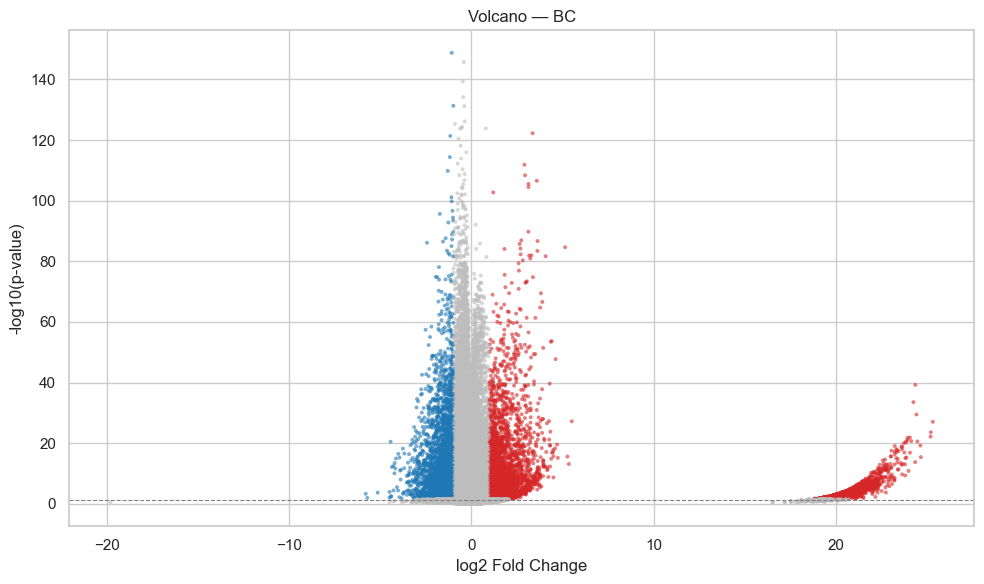

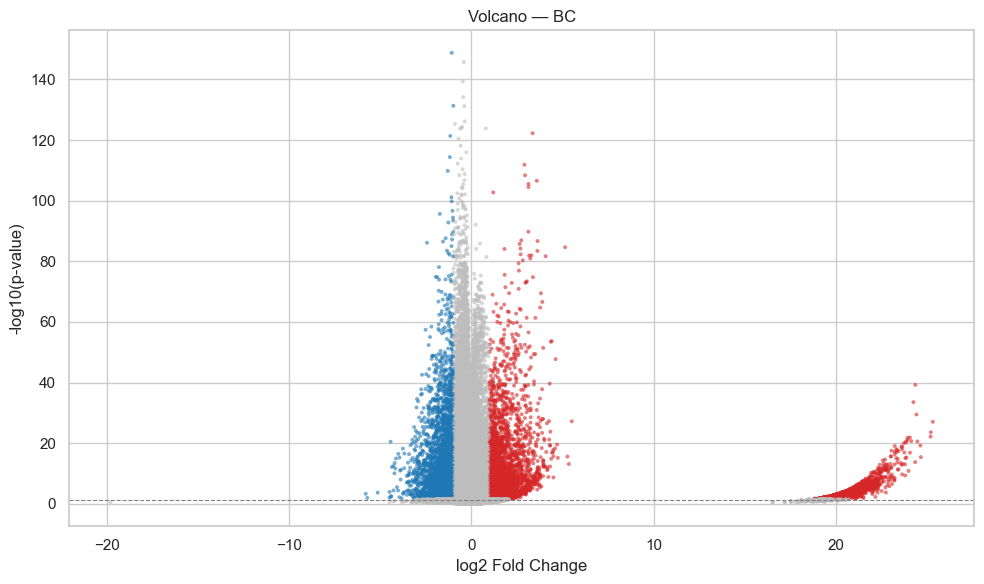

In [33]:
up_bc = deg_bc.deg_sig[deg_bc.deg_sig["direction"] == "upregulated"]["gene"].tolist()
down_bc = deg_bc.deg_sig[deg_bc.deg_sig["direction"] == "downregulated"]["gene"].tolist()
plot_volcano(deg_bc.deg_table, deg_bc.fc_threshold, exam_config.case_label, exam_config.ctrl_label, "Volcano — BC")


#### Heatmap (clustermap) DEG — Breast Cancer


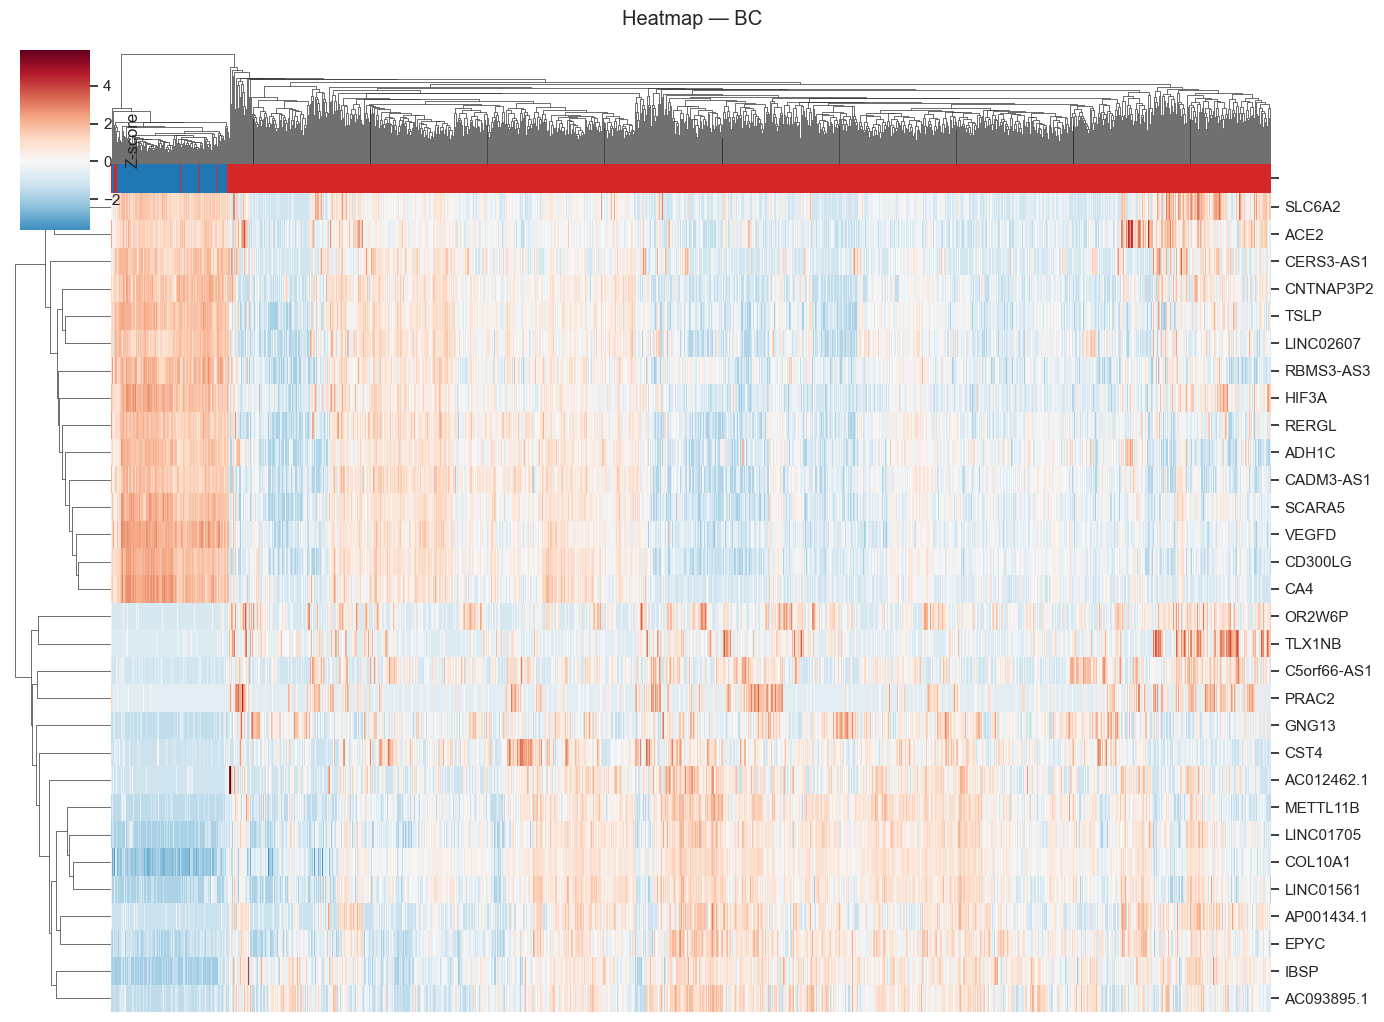

In [34]:
plot_deg_heatmap(deg_bc.X_deg, deg_bc.y, deg_bc.deg_sig, exam_config.case_label, exam_config.ctrl_label, "Heatmap — BC")


### §3.6 Train / Test split — BEFORE feature selection (Track B)

Anti-leakage: split on full DEG matrix before §3.4 FS.


In [35]:
y_ml_bc = deg_bc.y.reset_index(drop=True)
labels_ml_bc = deg_bc.labels.reset_index(drop=True)
deg_genes_bc = deg_bc.deg_sig["gene"].tolist()
X_fs_full_bc = minmax_deg_matrix(deg_bc.X_deg, deg_genes_bc)
s36_bc = run_section36_split(X_fs_full_bc, y_ml_bc, labels_ml_bc, exam_config, display_fn=display)


,Set,Samples,Case,Control
0,Train,760,689,71
1,Test,410,371,39
2,Total,1170,1060,110


### §3.4.0 Prepare FS context — Breast Cancer (train only)


In [36]:
if exam_config.fs_on_train_only:
    fs_ctx_bc = run_section34_prepare_on_train(deg_bc, s36_bc, exam_config, display_fn=display)
else:
    fs_ctx_bc = run_section34_prepare(deg_bc, exam_config)
print(f"FS matrix: {fs_ctx_bc.X_fs.shape} | pools up={len(fs_ctx_bc.up_pool)} down={len(fs_ctx_bc.down_pool)}")


,FS mode,train_samples,test_samples,deg_genes
0,train_only,760,410,7996


FS matrix: (1170, 7996) | pools up=300 down=300


### §3.4.1 Filter — Mutual Information (MI)


In [37]:
fs_341_bc = run_section341_mi(fs_ctx_bc, exam_config)
display({"up": fs_341_bc.up_gene, "down": fs_341_bc.down_gene})


{'up': 'CST4', 'down': 'SLC6A2'}

### §3.4.2 Wrapper — RFECV


In [38]:
fs_342_bc = run_section342_rfecv(fs_ctx_bc, exam_config)
display({"up": fs_342_bc.up_gene, "down": fs_342_bc.down_gene, "n_features_up": fs_342_bc.extra.get("up", {}).get("n_features_")})


{'up': 'ARHGAP16P', 'down': 'AC108477.1', 'n_features_up': np.int64(293)}

### §3.4.3 Embedded — Elastic Net + Gradient Boosting


In [39]:
fs_343_bc = run_section343_embedded(fs_ctx_bc, exam_config)
for r in fs_343_bc:
    print(r.method, "->", r.up_gene, r.down_gene)


Elastic Net -> AC112777.1 AL356275.1
Gradient Boosting Classifier -> AC083967.1 TRPM3


### §3.4.4 Feature Complementation — Table 3 + overlap


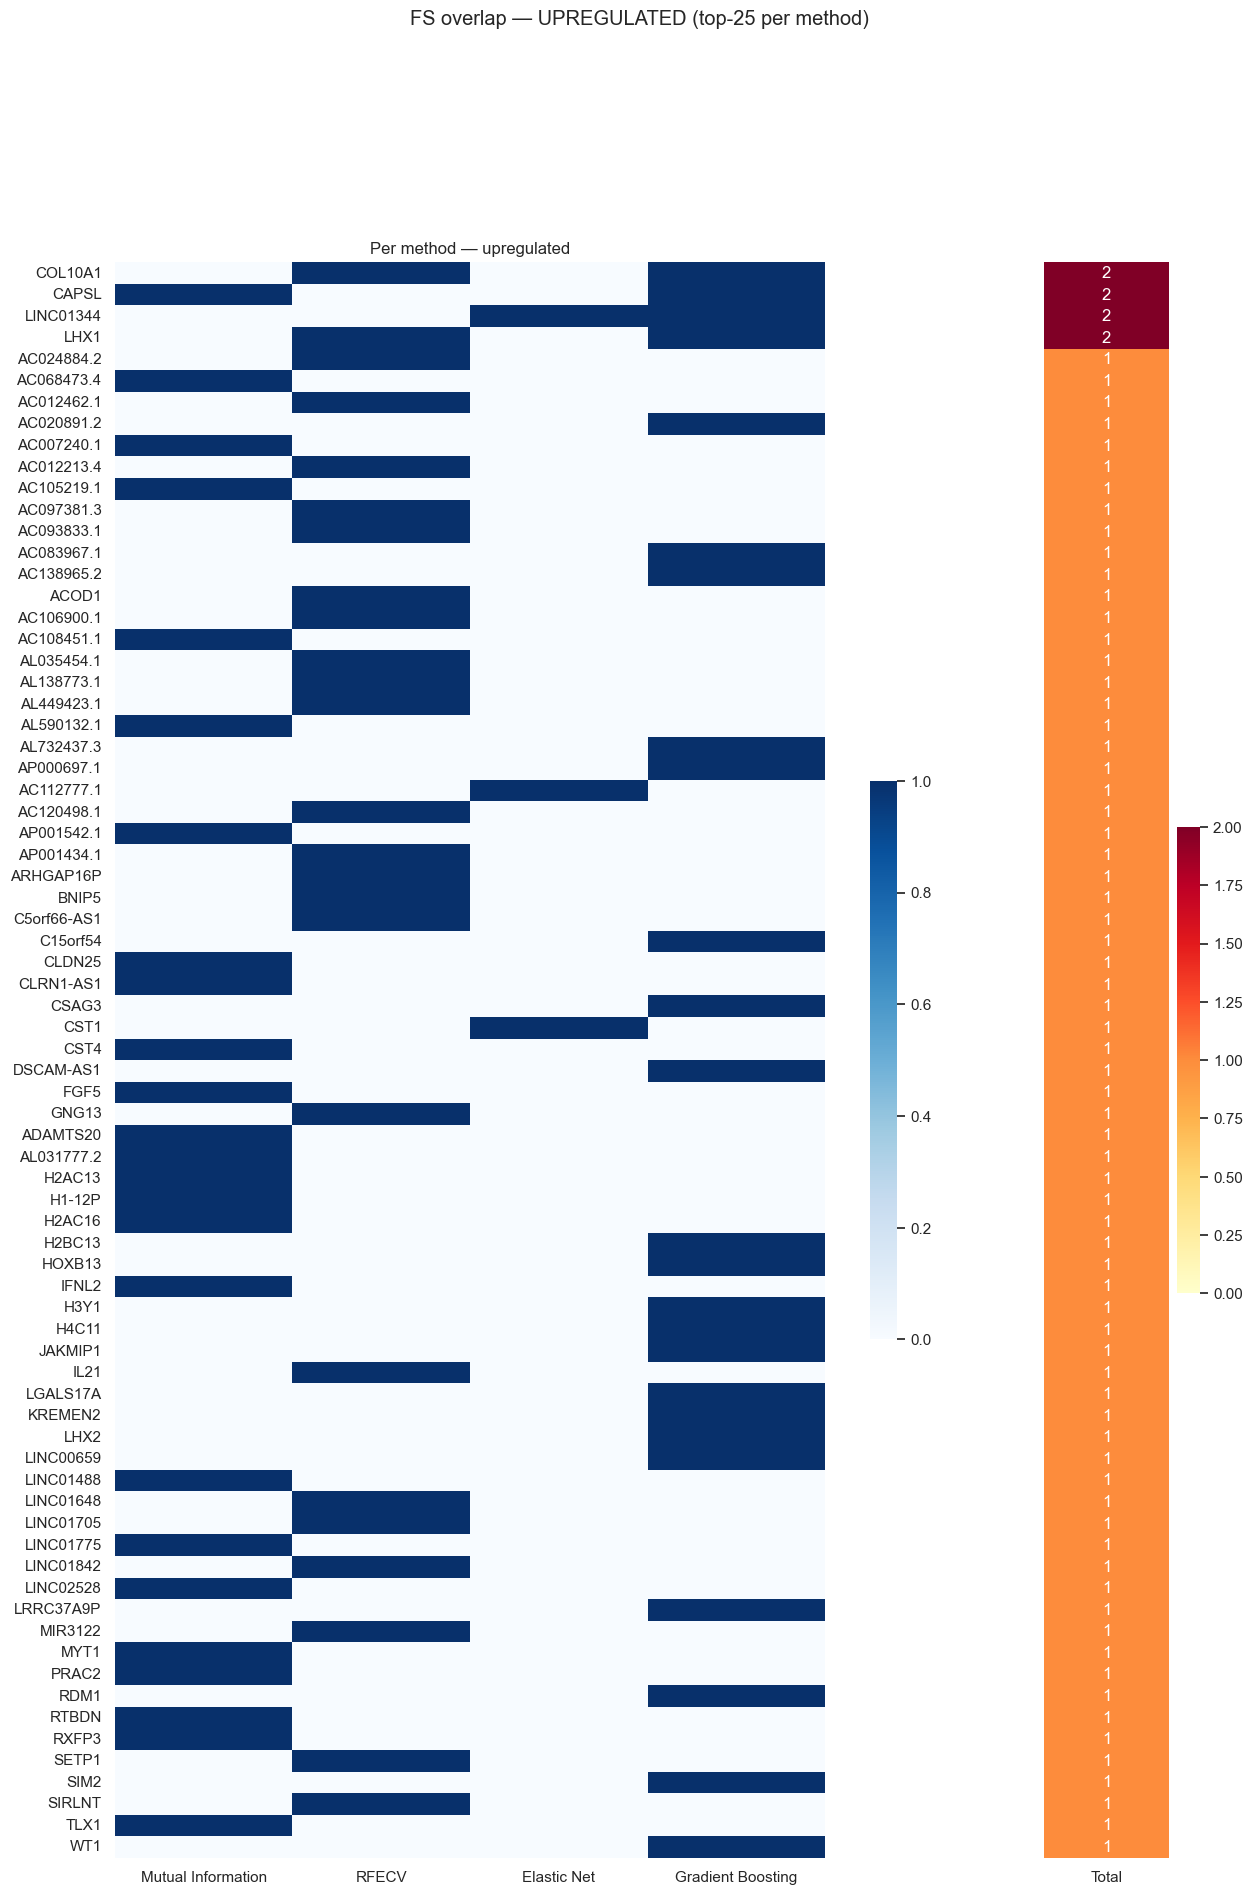

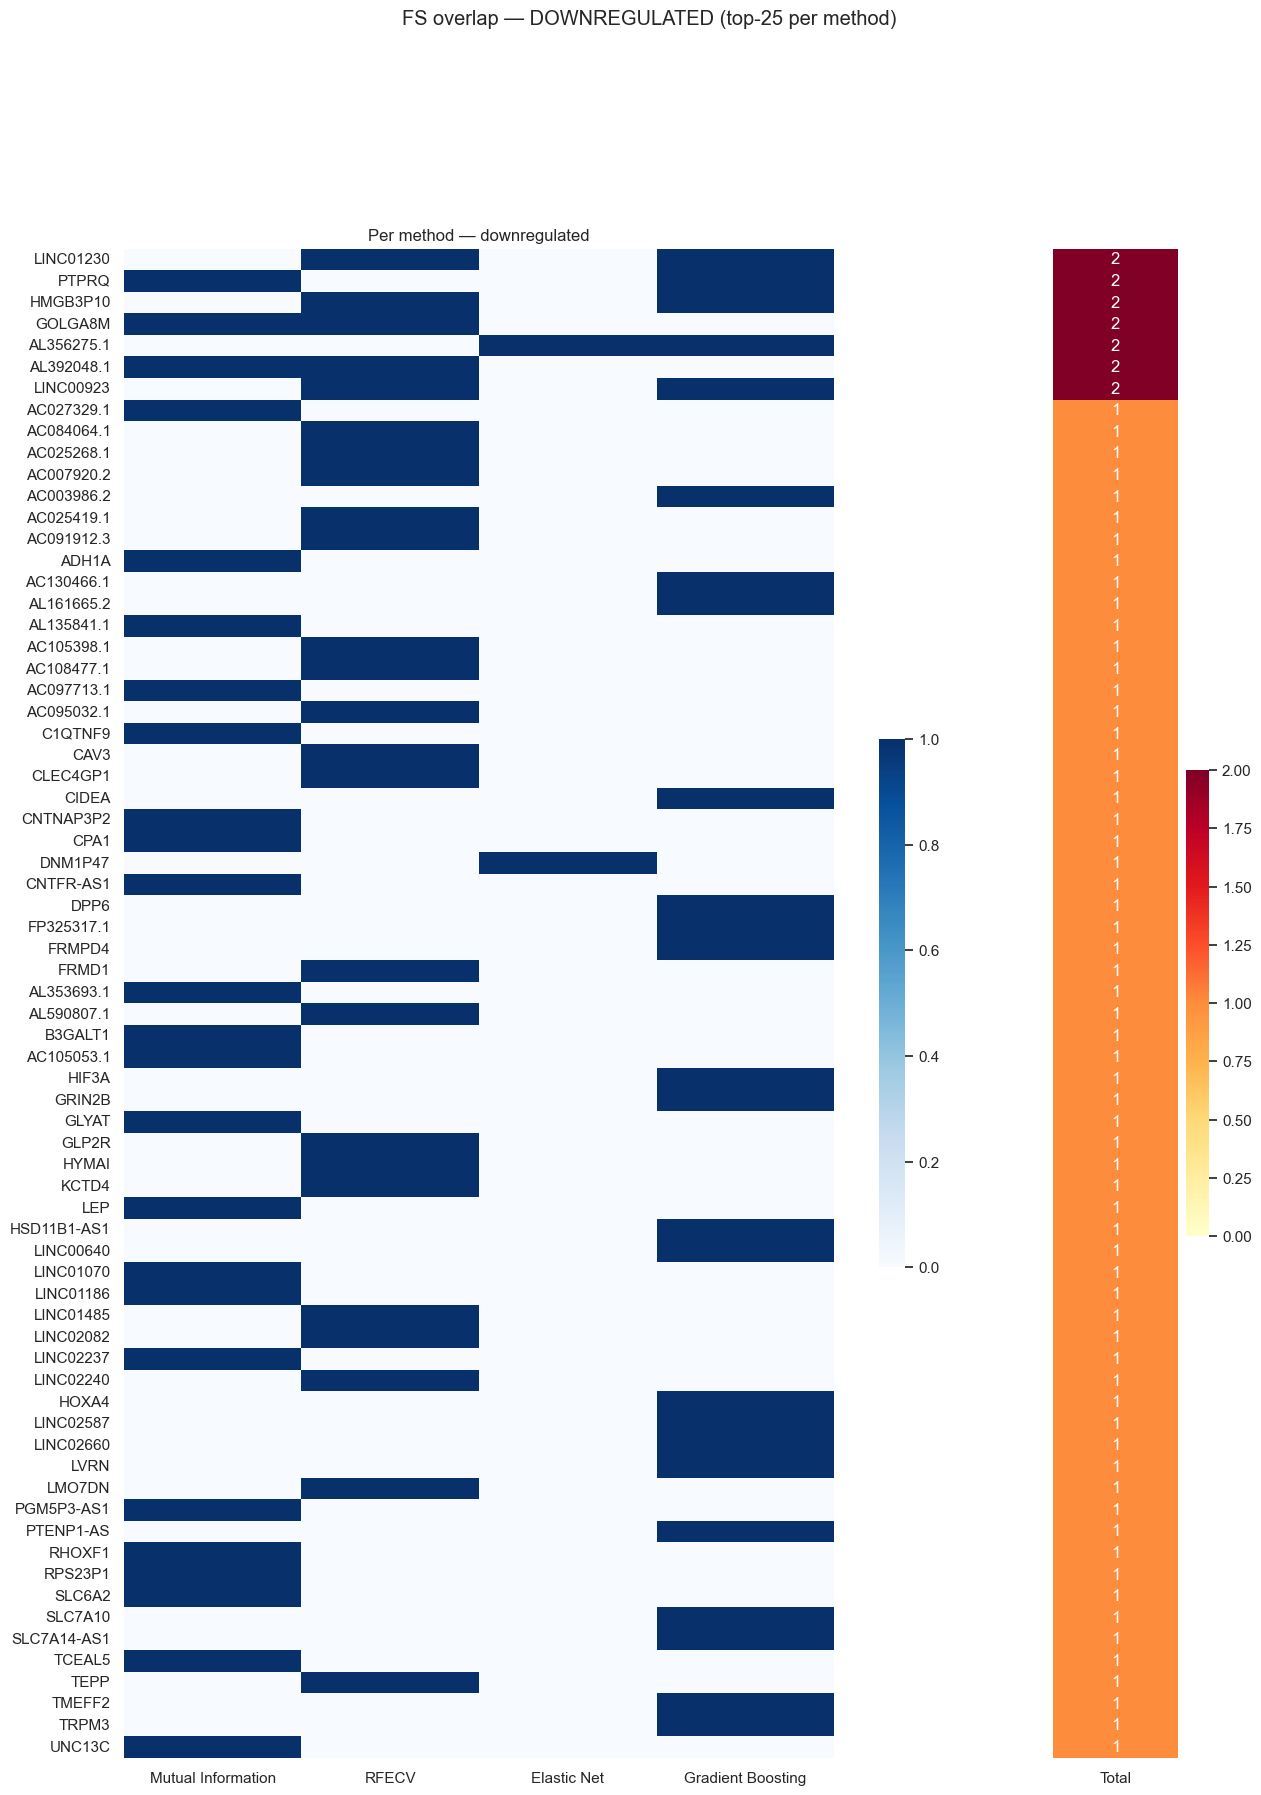

,FS Methods,Type of FS Method,Selected Upregulated,Selected Downregulated,N_up,N_down
0,Mutual Information Score,Filter,CST4,SLC6A2,25,25
1,RFECV,Wrapper,ARHGAP16P,AC108477.1,25,25
2,Elastic Net,Embedded,AC112777.1,AL356275.1,3,2
3,Gradient Boosting Classifier,Embedded,AC083967.1,TRPM3,25,25


,table3_master (#1 each method)
0,AC083967.1
1,AC108477.1
2,AC112777.1
3,AL356275.1
4,ARHGAP16P
5,CST4
6,SLC6A2
7,TRPM3



Union of all top-25 lists: 144 genes (UP=74, DOWN=70)

--- UPREGULATED: vote distribution (methods agreeing) ---


,votes,n_genes
0,2,4
1,1,70


Top consensus genes (UPREGULATED, votes >= 2):


...

,method,n_up,n_down,top5_up,top5_down
0,Gradient Boosting Classifier,25,25,"AC083967.1, AL732437.3, COL10A1, KREMEN2, DSCA...","TRPM3, HIF3A, HSD11B1-AS1, HOXA4, SLC7A14-AS1"



Master merged — UPREGULATED (sorted by method_votes, log2FC, qvalue):


,gene,method_votes,methods,log2FC,qvalue
0,COL10A1,2,"Gradient Boosting Classifier, RFECV",1.200462,2.908549e-100
1,LINC01344,2,"Elastic Net, Gradient Boosting Classifier",1.055803,1.068607e-35
2,CAPSL,2,"Gradient Boosting Classifier, Mutual Informati...",1.212211,3.654956e-32
3,LHX1,2,"Gradient Boosting Classifier, RFECV",2.409422,1.627279e-30
4,LINC01705,1,RFECV,2.942142,8.949150e-106
...,...,...,...,...,...
69,LINC01842,1,RFECV,1.150039,6.804075e-31
70,JAKMIP1,1,Gradient Boosting Classifier,1.468845,1.321228e-30
71,AC097381.3,1,RFECV,1.802868,1.860351e-30
72,MIR3122,1,RFECV,3.586199,1.860963e-30



Master merged — DOWNREGULATED (sorted by method_votes, log2FC, qvalue):


,gene,method_votes,methods,log2FC,qvalue
0,AL356275.1,2,"Elastic Net, Gradient Boosting Classifier",-1.779803,1.483020e-38
1,PTPRQ,2,"Gradient Boosting Classifier, Mutual Informati...",-1.039687,2.357023e-36
2,GOLGA8M,2,"Mutual Information Score, RFECV",-1.169522,2.301950e-35
3,LINC01230,2,"Gradient Boosting Classifier, RFECV",-1.499597,2.542908e-35
4,AL392048.1,2,"Mutual Information Score, RFECV",-0.989236,3.269304e-35
...,...,...,...,...,...
65,CAV3,1,RFECV,-1.472700,2.002558e-33
66,AC097713.1,1,Mutual Information Score,-2.224181,3.798953e-33
67,FRMPD4,1,Gradient Boosting Classifier,-1.207186,4.562408e-33
68,AC003986.2,1,Gradient Boosting Classifier,-1.251467,7.851963e-33


In [40]:
fs_344_bc = run_section344_complement(fs_ctx_bc, [fs_341_bc, fs_342_bc] + fs_343_bc, exam_config, display_fn=display)


In [41]:
table3_bc = fs_344_bc.table3
table3_master_bc = fs_344_bc.table3_master
master_bc = fs_344_bc.master_biomarkers
overlap_up_bc = fs_344_bc.overlap_up
overlap_down_bc = fs_344_bc.overlap_down
merged_up_bc = fs_344_bc.master_merged_up
merged_down_bc = fs_344_bc.master_merged_down

print("=" * 60)
print("TABLE 3 — Breast Cancer (#1 per method)")
print("=" * 60)
display(table3_bc[["FS Methods", "Type of FS Method",
                "Selected Upregulated", "Selected Downregulated", "N_up", "N_down"]])
print(f"\ntable3_master_bc ({len(table3_master_bc)} genes):")
print(table3_master_bc)


TABLE 3 — Breast Cancer (#1 per method)


,FS Methods,Type of FS Method,Selected Upregulated,Selected Downregulated,N_up,N_down
0,Mutual Information Score,Filter,CST4,SLC6A2,25,25
1,RFECV,Wrapper,ARHGAP16P,AC108477.1,25,25
2,Elastic Net,Embedded,AC112777.1,AL356275.1,3,2
3,Gradient Boosting Classifier,Embedded,AC083967.1,TRPM3,25,25



table3_master_bc (8 genes):
['AC083967.1', 'AC108477.1', 'AC112777.1', 'AL356275.1', 'ARHGAP16P', 'CST4', 'SLC6A2', 'TRPM3']


In [42]:
vote_col_bc = "votes" if "votes" in overlap_up_bc.columns else "Total"
print("--- UPREGULATED: top votes ---")
display(overlap_up_bc.sort_values(vote_col_bc, ascending=False).head(25))
print("\n--- DOWNREGULATED: top votes ---")
display(overlap_down_bc.sort_values(vote_col_bc, ascending=False).head(25))
screened_bc = screened_consensus_genes(overlap_up_bc, overlap_down_bc, min_votes=2)
print(f"Screened biomarkers (votes>=2): {len(screened_bc)}")


--- UPREGULATED: top votes ---


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
COL10A1,0,1,0,1,2
CAPSL,1,0,0,1,2
LINC01344,0,0,1,1,2
LHX1,0,1,0,1,2
AC024884.2,0,1,0,0,1
AC068473.4,1,0,0,0,1
AC012462.1,0,1,0,0,1
AC020891.2,0,0,0,1,1
AC007240.1,1,0,0,0,1
AC012213.4,0,1,0,0,1



--- DOWNREGULATED: top votes ---


,Mutual Information,RFECV,Elastic Net,Gradient Boosting,votes
LINC01230,0,1,0,1,2
PTPRQ,1,0,0,1,2
HMGB3P10,0,1,0,1,2
GOLGA8M,1,1,0,0,2
AL356275.1,0,0,1,1,2
AL392048.1,1,1,0,0,2
LINC00923,0,1,0,1,2
AC027329.1,1,0,0,0,1
AC084064.1,0,1,0,0,1
AC025268.1,0,1,0,0,1


Screened biomarkers (votes>=2): 11


#### HFCP — screened biomarkers (Track B)


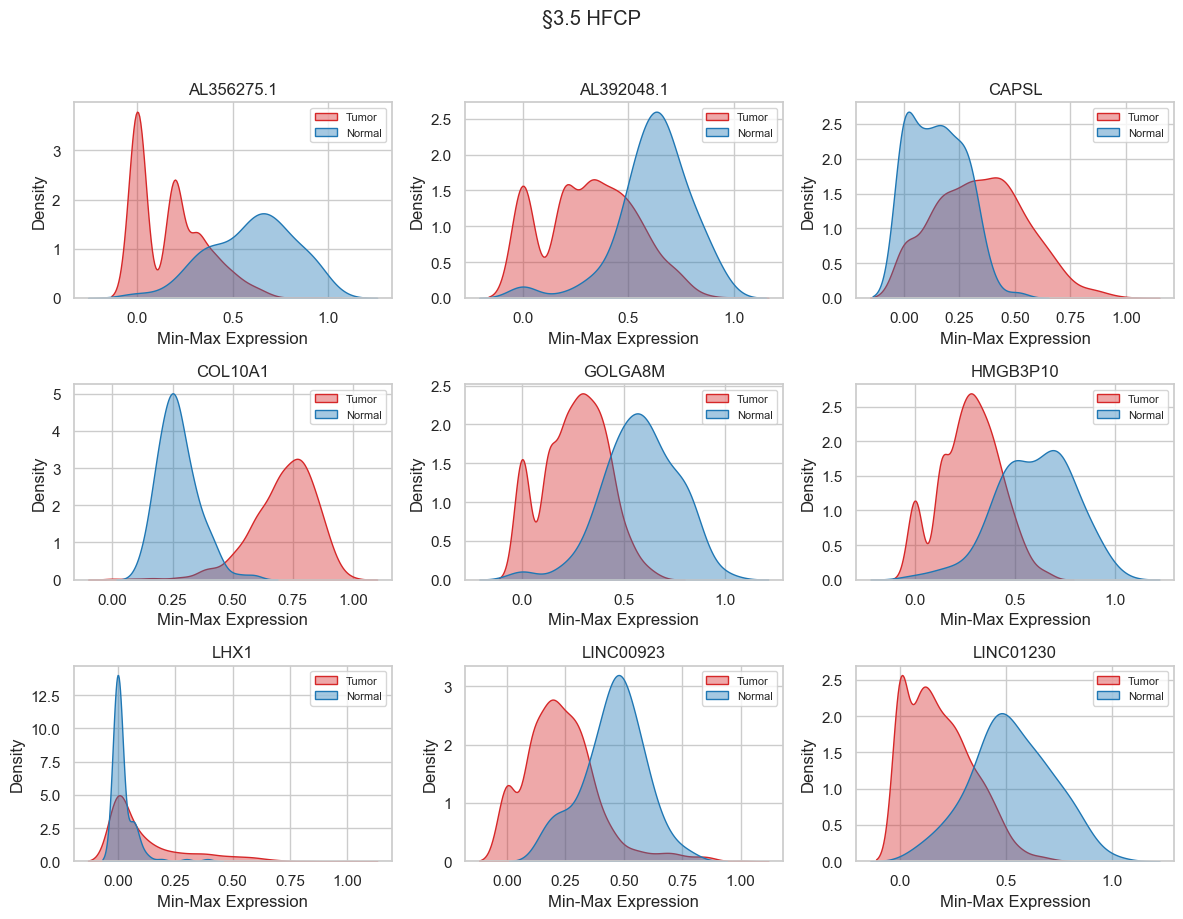

,Gene Biomarker,Direction,Case Mean,Control Mean,t-Statistic,p-Value
0,AL356275.1,downregulated,0.175307,0.601967,-19.622602,5.728491e-40
1,AL392048.1,downregulated,0.313206,0.621756,-17.044104,1.558785e-36
2,CAPSL,upregulated,0.344513,0.148694,14.934906,2.108006e-33
3,COL10A1,upregulated,0.709876,0.273025,48.416777,1.782496e-103
4,GOLGA8M,downregulated,0.257651,0.579553,-18.005411,1.082540e-36
5,HMGB3P10,downregulated,0.273928,0.600123,-17.465972,3.888551e-35
6,LHX1,upregulated,0.120693,0.022718,12.852379,1.049230e-31
7,LINC00923,downregulated,0.229455,0.453857,-16.546386,4.361421e-35
8,LINC01230,downregulated,0.185318,0.524013,-18.094599,1.200414e-36


In [43]:
if screened_bc:
    s35_screened_bc = run_section35_hfcp(fs_ctx_bc.X_fs, deg_bc.y, screened_bc, deg_bc.deg_table, exam_config, display_fn=display)


### §3.5 HFCP — Breast Cancer biomarkers


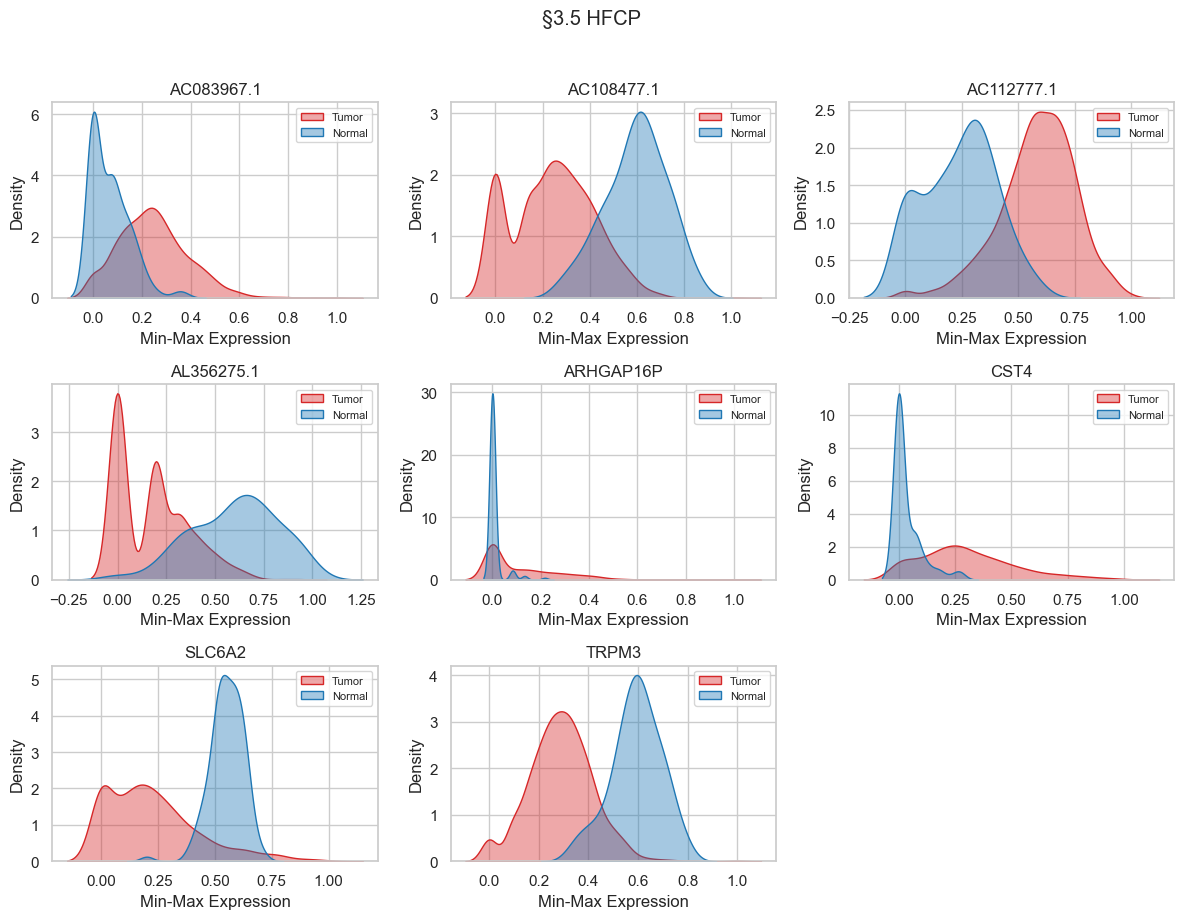

,Gene Biomarker,Direction,Case Mean,Control Mean,t-Statistic,p-Value
0,AC083967.1,upregulated,0.245817,0.068329,20.302051,6.157831e-50
1,AC108477.1,downregulated,0.241439,0.594730,-26.127635,7.648799e-58
2,AC112777.1,upregulated,0.583259,0.238194,21.609418,8.298271e-46
3,AL356275.1,downregulated,0.175307,0.601967,-19.622602,5.728491e-40
4,ARHGAP16P,upregulated,0.112120,0.008190,18.841949,1.840125e-65
5,CST4,upregulated,0.299123,0.034132,29.685377,3.019897e-106
6,SLC6A2,downregulated,0.224508,0.550011,-34.590886,1.428419e-110
7,TRPM3,downregulated,0.288771,0.592155,-29.171160,2.740774e-63


In [44]:
s35_bc = run_section35_hfcp(fs_ctx_bc.X_fs, deg_bc.y, table3_master_bc, deg_bc.deg_table, exam_config, display_fn=display)
s36_ml_bc = slice_section36_genes(s36_bc, table3_master_bc)


### §3.7 Balance training set — RUS (exam)

Single balanced train set via random under-sampling. **Never** balance the test set.


In [45]:
s37_bc = run_section37_balance(s36_ml_bc.X_train, s36_ml_bc.y_train, exam_config, display_fn=display)
print("Method:", s37_bc.method)
print("Before:", s37_bc.before)
print("After:", s37_bc.after)

# RUS on full DEG matrix (for A2-style Q2 baseline / univariate sections)
s37_deg_bc = run_section37_balance(s36_bc.X_train, s36_bc.y_train, exam_config, display_fn=display)
deg_pool_bc = top_deg_features_by_qvalue(deg_bc.deg_sig, exam_config.baseline_max_features)
print(f"Top-DEG pool for baseline/univariate: {len(deg_pool_bc)} genes")


,before,after,method
0,"{1: 689, 0: 71}","{0: 71, 1: 71}",rus


Method: rus
Before: {1: 689, 0: 71}
After: {0: 71, 1: 71}


,before,after,method
0,"{1: 689, 0: 71}","{0: 71, 1: 71}",rus


Top-DEG pool for baseline/univariate: 500 genes


### §3.10a Baseline models — all top-DEGs (A2-style, breast cancer)

Multi-model comparison (LR, RF, Extra Trees, DT) with **validation-tuned threshold** (`optimize_metric="accuracy"`).


,Model,N Feats,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP,Threshold,policy_status
1,Random Forest (All 500),500,0.9049,0.9049,1.0000,0.9501,0.9794,0.5721,0.9225,0.0000,0,39,0,371,0.46,Best accuracy (validation)
2,Extra Trees (All 500),500,0.9049,0.9049,1.0000,0.9501,0.9794,0.6806,0.9494,0.0000,0,39,0,371,0.47,Best accuracy (validation)
0,Logistic Regression (All 500),500,0.9024,0.9046,0.9973,0.9487,0.9773,0.6321,0.9444,0.0000,0,39,1,370,0.47,Best accuracy (validation)
3,Decision Tree (All 500),500,0.8732,0.9908,0.8679,0.9253,0.8900,0.8822,0.9803,0.9231,36,3,49,322,0.49,Best accuracy (validation)


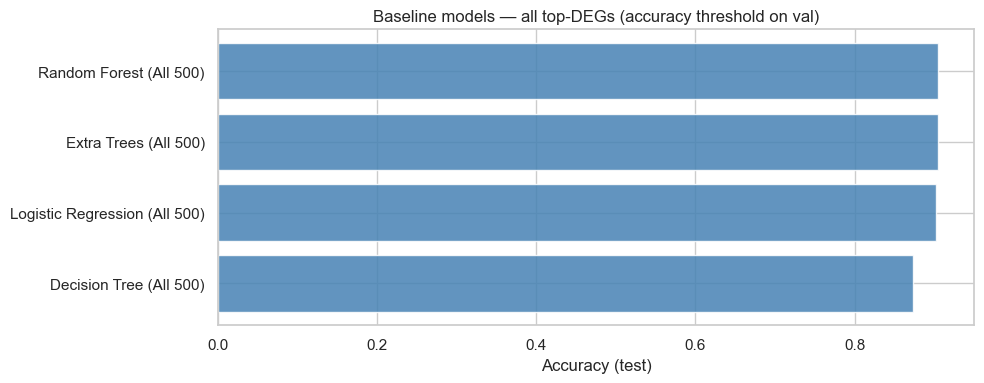

In [46]:
baseline_all_models_bc = run_all_models_baseline(
    s37_deg_bc.X_train, s37_deg_bc.y_train,
    s36_bc.X_test, s36_bc.y_test,
    deg_pool_bc, exam_config, display_fn=display,
)


### §3.10a2 Univariate feature ranking (A2-style)

Pearson, ANOVA, ReliefF, Mutual Information on **train only** (top-DEG pool).


Univariate rank table: 400 rows


,method,feature_scope,rank,feature,score
0,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",1,AL356275.1,0.234537
1,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",2,LINC01266,0.220377
2,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",3,CAVIN2-AS1,0.219935
3,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",4,OVCH1,0.218512
4,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",5,DNM1P47,0.217919
5,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",6,PSAT1P3,0.217652
6,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",7,GOLGA8M,0.214520
7,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",8,AC036108.2,0.212884
8,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",9,AL356489.3,0.209062
9,Pearson |r| with Target,"numeric genes, |Pearson r| with binary label",10,LINC01522,0.208916


Univariate methods: 4 | rank table top=100 | overlap top=25
Saved bc_univariate_rank_top100.csv


,feature,Pearson |r| with Target,ANOVA F-Statistic,ReliefF Weight,Mutual Information,n_methods
6,AC027329.1,True,True,True,True,4
40,FDPSP8,True,True,True,False,3
23,AL356275.1,True,True,True,False,3
5,AC025470.2,True,True,False,False,2
10,AC108734.4,True,True,False,False,2
3,AC012409.3,True,True,False,False,2
1,AC009242.1,True,True,False,False,2
61,PCK1,True,True,False,False,2
60,OVCH1,True,True,False,False,2
64,PSAT1P3,True,True,False,False,2


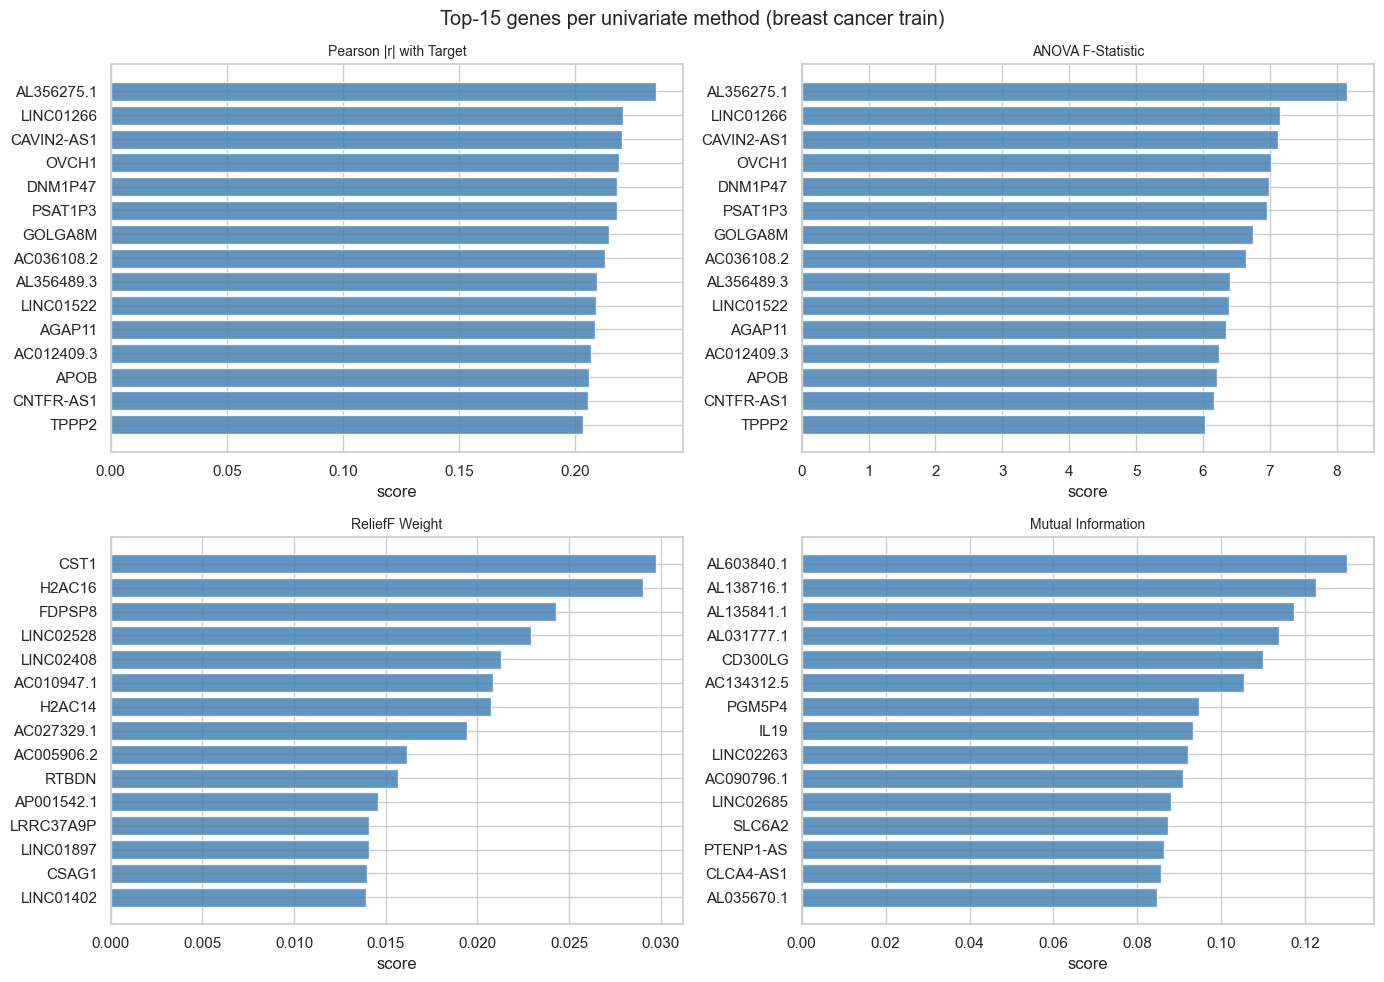

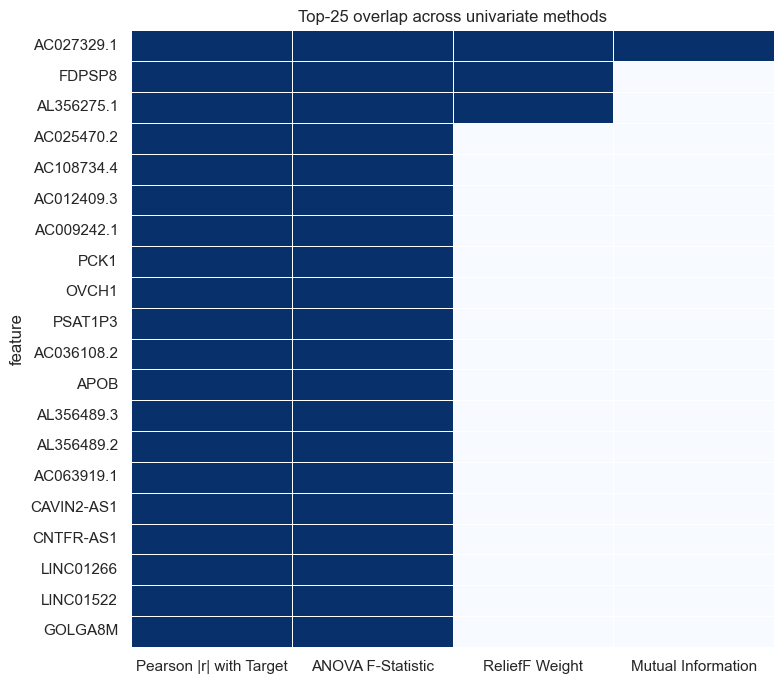

(                      method                                 feature_scope  \
 0    Pearson |r| with Target  numeric genes, |Pearson r| with binary label   
 1    Pearson |r| with Target  numeric genes, |Pearson r| with binary label   
 2    Pearson |r| with Target  numeric genes, |Pearson r| with binary label   
 3    Pearson |r| with Target  numeric genes, |Pearson r| with binary label   
 4    Pearson |r| with Target  numeric genes, |Pearson r| with binary label   
 ..                       ...                                           ...   
 395       Mutual Information    numeric genes, sklearn mutual_info_classif   
 396       Mutual Information    numeric genes, sklearn mutual_info_classif   
 397       Mutual Information    numeric genes, sklearn mutual_info_classif   
 398       Mutual Information    numeric genes, sklearn mutual_info_classif   
 399       Mutual Information    numeric genes, sklearn mutual_info_classif   
 
      rank     feature     score  
 0       1  AL3

In [47]:
uni_scores_bc = compute_univariate_scores(
    s37_deg_bc.X_train, s37_deg_bc.y_train, exam_config, gene_pool=deg_pool_bc,
)
uni_rank_bc = build_univariate_rank_table(uni_scores_bc, exam_config.univariate_rank_top)
print(f"Univariate rank table: {len(uni_rank_bc)} rows")
display(uni_rank_bc.head(40))
plot_univariate_summary(uni_scores_bc, exam_config, display_fn=display)


### §3.10b RF quick compare — univariate methods (A2-style)

Baseline RF vs top-K per univariate method vs overlap panel.


,source,N Feats,Accuracy,Recall,F2,AUC_PR,Precision,Specificity,Threshold,policy_status
0,Baseline RF (500),500,0.9049,1.0000,0.9794,0.9225,0.9049,0.0000,0.46,Best accuracy (validation)
3,ReliefF Weight,25,0.9049,1.0000,0.9794,0.9841,0.9049,0.0000,0.46,Best accuracy (validation)
4,Mutual Information,25,0.9049,1.0000,0.9794,0.8569,0.9049,0.0000,0.46,Best accuracy (validation)
1,Pearson |r| with Target,25,0.5488,0.6038,0.6415,0.7771,0.8550,0.0256,0.63,Best accuracy (validation)
2,ANOVA F-Statistic,25,0.5488,0.6038,0.6415,0.7771,0.8550,0.0256,0.63,Best accuracy (validation)
5,Overlap top-25,25,0.5073,0.5580,0.5986,0.8013,0.8449,0.0256,0.66,Best accuracy (validation)


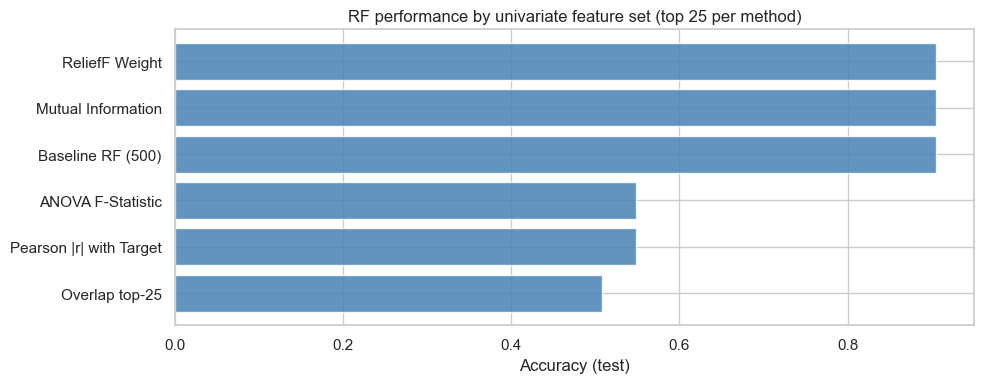

In [48]:
uni_cmp_bc, baseline_rf_bc, _ = run_univariate_quick_compare(
    s37_deg_bc.X_train, s37_deg_bc.y_train,
    s36_bc.X_test, s36_bc.y_test,
    uni_scores_bc, exam_config,
    k=exam_config.univariate_quick_k,
    gene_pool=deg_pool_bc,
    display_fn=display,
)


### §3.8 LOOCV — Breast Cancer


In [49]:
s38_bc = run_section38_loocv(s37_bc.X_train, s37_bc.y_train, table3_master_bc, exam_config, display_fn=display, train_label="rus")


,LOOCV train,CM check
0,"Normal=71, Tumor=71, total=142 (rus)","TN+FP=71, FN+TP=71 (sumas por fila = train, no..."


,Model,LOOCV Accuracy,TN,FP,FN,TP
7,XGBoost,0.5634,67,4,58,13
0,Logistic Regression,0.5563,65,6,57,14
2,Gaussian NB,0.5563,65,6,57,14
1,KNN,0.5563,65,6,57,14
3,SVC,0.5563,65,6,57,14
6,MLP,0.5563,65,6,57,14
5,Random Forest,0.5423,65,6,59,12
4,Decision Tree,0.5352,68,3,63,8


### §3.9 Train supervised classifiers


In [50]:
s39_bc = run_section39_train(s37_bc.X_train, s37_bc.y_train, table3_master_bc, exam_config)
print("Models trained:", list(s39_bc.models.keys()))


Models trained: ['Logistic Regression', 'KNN', 'Gaussian NB', 'SVC', 'Decision Tree', 'Random Forest', 'MLP', 'XGBoost']


### §3.10 Test-set evaluation — Breast Cancer


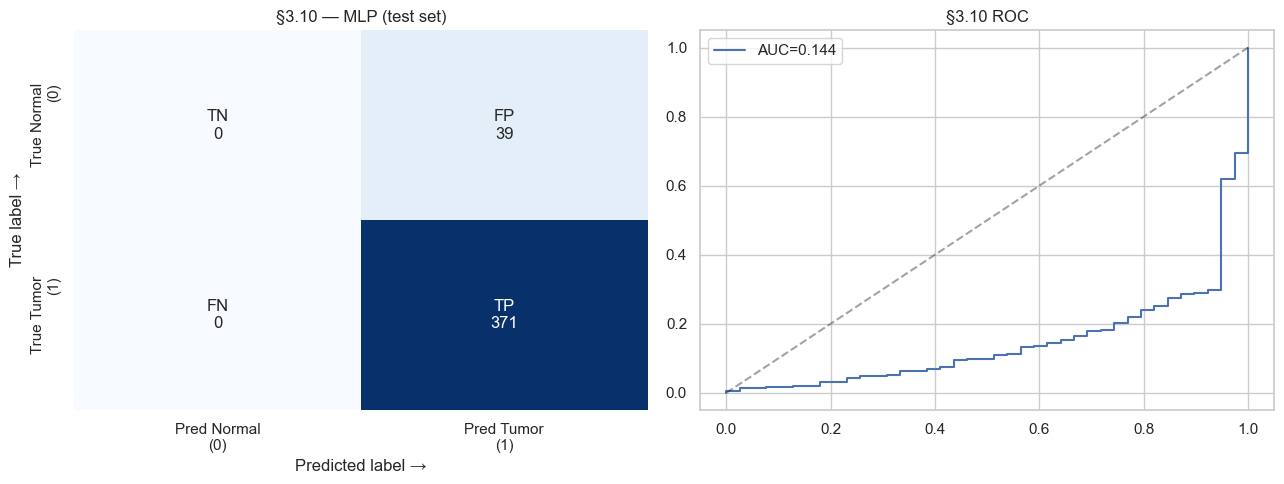

,Model,Test Accuracy,Balanced Acc,Precision,Recall,Specificity,F1,TN,FP,FN,TP,AUC-ROC
6,MLP,0.9049,0.5000,0.9049,1.0000,0.0000,0.9501,0,39,0,371,0.1438
0,Logistic Regression,0.9024,0.4987,0.9046,0.9973,0.0000,0.9487,0,39,1,370,0.1343
2,Gaussian NB,0.9024,0.4987,0.9046,0.9973,0.0000,0.9487,0,39,1,370,0.4175
1,KNN,0.6902,0.3814,0.8789,0.7628,0.0000,0.8167,0,39,88,283,0.2933
5,Random Forest,0.5927,0.3504,0.8669,0.6496,0.0513,0.7427,2,37,130,241,0.2521
7,XGBoost,0.5634,0.3457,0.8636,0.6146,0.0769,0.7181,3,36,143,228,0.3033
4,Decision Tree,0.5171,0.4578,0.8914,0.5310,0.3846,0.6655,15,24,174,197,0.4879
3,SVC,0.5122,0.3174,0.8519,0.5580,0.0769,0.6743,3,36,164,207,0.8019


In [51]:
s310_bc = run_section310_evaluate(
    s37_bc.X_train, s37_bc.y_train,
    s36_ml_bc.X_test, s36_ml_bc.y_test,
    table3_master_bc, exam_config, display_fn=display,
)


### §3.10c Syed/A2 feature-set comparison (breast cancer)

Merged, Merged pruned, DISR, PCA vs 8-gene Table 3 panel. Objective: `exam_config.optimize_metric = "accuracy"`.


Breast cancer Table 3 genes (this track — NOT IBD):
['AC083967.1', 'AC108477.1', 'AC112777.1', 'AL356275.1', 'ARHGAP16P', 'CST4', 'SLC6A2', 'TRPM3']


,Feature_Set,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_F2,Test_Balanced_Acc,Test_TN,Test_FP,...,Test_TP,Test_AUC,Test_AUC-ROC,Test_AUC_PR,Test_Threshold,Test_n_features,Train_Recall,optimize_metric,n_features,Threshold
4,Merged_pruned,0.9902,0.9973,0.9919,0.9744,0.9946,0.9930,0.9831,38.0,1.0,...,368.0,0.9985,0.9985,0.9998,0.52,138.0,1.0,accuracy,NaN,NaN
5,DISR,0.9902,1.0000,0.9892,1.0000,0.9946,0.9914,0.9946,39.0,0.0,...,367.0,0.9990,0.9990,0.9999,0.61,10.0,1.0,accuracy,NaN,NaN
3,Merged,0.9878,0.9946,0.9919,0.9487,0.9933,0.9924,0.9703,37.0,2.0,...,368.0,0.9986,0.9986,0.9999,0.51,144.0,1.0,accuracy,NaN,NaN
0,Baseline_top_DEGs,0.9854,0.9893,0.9946,0.8974,0.9919,0.9935,0.9460,35.0,4.0,...,369.0,0.9991,0.9991,0.9999,0.29,500.0,1.0,accuracy,NaN,NaN
1,Table3_8genes (Tumor),0.9805,0.9946,0.9838,0.9487,0.9892,0.9860,0.9663,37.0,2.0,...,365.0,0.9955,0.9955,0.9995,0.57,8.0,1.0,accuracy,NaN,NaN
2,Screened_consensus,0.9780,1.0000,0.9757,1.0000,0.9877,0.9805,0.9879,39.0,0.0,...,362.0,0.9979,0.9979,0.9998,0.69,11.0,1.0,accuracy,NaN,NaN
6,PCA_n50,0.9780,NaN,0.9919,0.8462,0.9879,NaN,0.9190,NaN,NaN,...,NaN,NaN,0.9938,NaN,NaN,NaN,NaN,accuracy,50.0,0.45


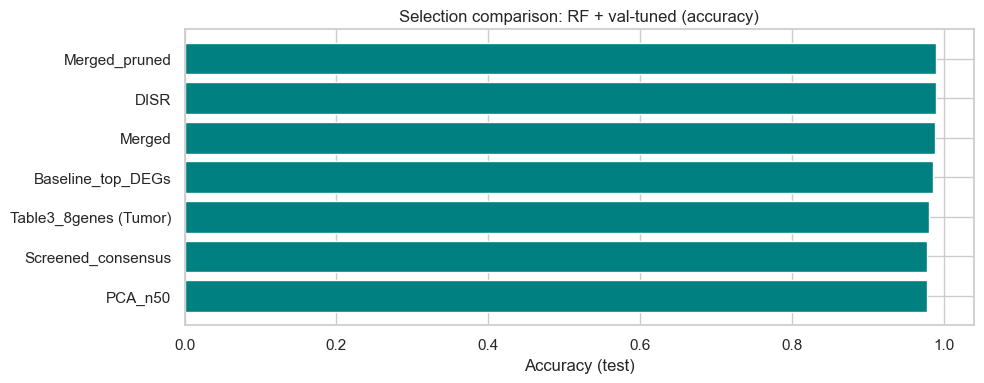

In [52]:
print("Breast cancer Table 3 genes (this track — NOT IBD):")
print(table3_master_bc)
feature_sets_bc = build_feature_sets(fs_344_bc, deg_bc.deg_sig, exam_config, s36_bc.X_train, s36_bc.y_train)
baseline_cmp_bc, baseline_models_bc = run_baseline_suite(
    s36_bc.X_train, s36_bc.y_train, s36_bc.X_test, s36_bc.y_test,
    feature_sets_bc, exam_config, display_fn=display,
)


### §3.11 External validation — deferred to Question 3

Breast cancer biomarkers will be validated on **GSE75214** in Question 3. `ExamConfig` sets `external_cohorts=[]` so no IBD GEO cohorts run here.


### §3.12 Pathway analysis — Breast Cancer biomarkers


In [53]:
s312_bc = run_section312_pathway(table3_master_bc, exam_config, display_fn=display)


,gene,in_master_set
0,VWF,False
1,IL1RL1,False
2,DENND2B,False
3,MMP14,False
4,NAAA,False
5,PANK1,False


'Run WebGestalt 2024 ORA (GO + KEGG) on paper final six genes or your master biomarker set. Significance cutoff p < 0.05.'

### Track B — Results summary (Question 1 pipeline)

Use these results for your **Question 2 written discussion** (§3.10a baseline, §3.10b univariate, §3.10c feature sets, §3.10 Syed classifiers).


In [54]:
print("=== Track B — Summary (Q1 pipeline) ===")
print("§2.2 preprocessing:", s32_bc.prep_info)
display(s32_bc.comparison)
display(deg_bc.summary)
print(f"Biomarkers (Table 3): {table3_master_bc}")
print(f"RUS train balance: {s37_bc.after}")
if s310_bc.best_model:
    print(f"Best test model: {s310_bc.best_model}")
display(s310_bc.performance)
if 'baseline_cmp_bc' in dir() and baseline_cmp_bc is not None and len(baseline_cmp_bc):
    print("\nBest Syed/A2 feature set (§3.10c):")
    display(baseline_cmp_bc.head(3))
if 'uni_cmp_bc' in dir() and uni_cmp_bc is not None and len(uni_cmp_bc):
    print("\nBest univariate RF (§3.10b):")
    display(uni_cmp_bc.head(3))
if 'baseline_all_models_bc' in dir() and baseline_all_models_bc is not None and len(baseline_all_models_bc):
    print("\nBest baseline model (§3.10a):")
    display(baseline_all_models_bc.head(2))


=== Track B — Summary (Q1 pipeline) ===
§2.2 preprocessing: {'quasi_constant_removed': 1456, 'quasi_constant_removed_genes': ['TTTY1', 'VCY', 'CDY2B', 'GDF1', 'AC027088.1', 'TTTY7', 'TTTY7B', 'TSPY2', 'RBMY1F', 'PRY2', 'TSPY14P', 'CDY1', 'CSPG4P4Y', 'CSPG4P3Y', 'AC007967.1', 'AC092634.1', 'TGIF2LY', 'DEFB104A', 'DEFB103A', 'DEFB104B', 'OR7E125P', 'OR4F4', 'TTTY11', 'PRORY', 'TTTY8', 'PMCH', 'BPY2', 'OR4G2P', 'TTTY13', 'SSXP4', 'TTTY8B', 'BPY2C', 'DEFB105A', 'DEFB107A', 'DEFB106A', 'DEFB105B', 'DEFB106B', 'LCE3B', 'TSPY13P', 'DAZ1', 'ANKRD36P1', 'DEFB107B', 'MIR375', 'MIR1-1', 'MIR208A', 'MIR96', 'AC069285.1', 'RNU6-896P', 'RNU6-664P', 'RNA5SP26', 'AL356754.1', 'RNA5SP347', 'AL512272.1', 'RNU6-369P', 'AC124254.1', 'RNU6-543P', 'RNU6-845P', 'SNORD115-12', 'AC092324.1', 'RNU1-70P', 'RNU6-462P', 'SNORD115-29', 'SNORD115-2', 'RNU6-655P', 'RNU6-78P', 'SNORD115-9', 'RNA5SP374', 'RNU6-582P', 'RNU6-330P', 'AC093872.1', 'RNU6-1252P', 'SNORD115-19', 'RNA5SP98', 'RNU6-812P', 'RN7SKP63', 'RNA5SP326

,Stage,Note,n_samples,n_genes,min,max,mean,std
0,Before preprocessing,,1191,56936,0.0,7.683396e+06,1017.846802,9751.962891
1,After log2(x+1),log2(x+1),1191,56936,0.0,2.287331e+01,3.522485,4.372971
2,After quasi-constant removal,removed 1456 genes (variance <= 0.01),1191,55480,0.0,2.287331e+01,3.614822,4.392171
3,After IQR outlier removal,removed 21 samples,1170,55480,0.0,2.274558e+01,3.610543,4.395582
4,After Min–Max scaling,"values scaled to [0, 1]",1170,55480,0.0,1.000000e+00,0.267785,0.270230


,Category,Our_count
0,Upregulated,4963
1,Downregulated,3033
2,Total DEG,7996


Biomarkers (Table 3): ['AC083967.1', 'AC108477.1', 'AC112777.1', 'AL356275.1', 'ARHGAP16P', 'CST4', 'SLC6A2', 'TRPM3']
RUS train balance: {0: 71, 1: 71}
Best test model: MLP


,Model,Test Accuracy,Balanced Acc,Precision,Recall,Specificity,F1,TN,FP,FN,TP,AUC-ROC
6,MLP,0.9049,0.5000,0.9049,1.0000,0.0000,0.9501,0,39,0,371,0.1438
0,Logistic Regression,0.9024,0.4987,0.9046,0.9973,0.0000,0.9487,0,39,1,370,0.1343
2,Gaussian NB,0.9024,0.4987,0.9046,0.9973,0.0000,0.9487,0,39,1,370,0.4175
1,KNN,0.6902,0.3814,0.8789,0.7628,0.0000,0.8167,0,39,88,283,0.2933
5,Random Forest,0.5927,0.3504,0.8669,0.6496,0.0513,0.7427,2,37,130,241,0.2521
7,XGBoost,0.5634,0.3457,0.8636,0.6146,0.0769,0.7181,3,36,143,228,0.3033
4,Decision Tree,0.5171,0.4578,0.8914,0.5310,0.3846,0.6655,15,24,174,197,0.4879
3,SVC,0.5122,0.3174,0.8519,0.5580,0.0769,0.6743,3,36,164,207,0.8019


...

,Feature_Set,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_F2,Test_Balanced_Acc,Test_TN,Test_FP,...,Test_TP,Test_AUC,Test_AUC-ROC,Test_AUC_PR,Test_Threshold,Test_n_features,Train_Recall,optimize_metric,n_features,Threshold
4,Merged_pruned,0.9902,0.9973,0.9919,0.9744,0.9946,0.9930,0.9831,38.0,1.0,...,368.0,0.9985,0.9985,0.9998,0.52,138.0,1.0,accuracy,NaN,NaN
5,DISR,0.9902,1.0000,0.9892,1.0000,0.9946,0.9914,0.9946,39.0,0.0,...,367.0,0.9990,0.9990,0.9999,0.61,10.0,1.0,accuracy,NaN,NaN
3,Merged,0.9878,0.9946,0.9919,0.9487,0.9933,0.9924,0.9703,37.0,2.0,...,368.0,0.9986,0.9986,0.9999,0.51,144.0,1.0,accuracy,NaN,NaN



Best univariate RF (§3.10b):


,Accuracy,Precision,Recall,Specificity,F1,F2,Balanced_Acc,TN,FP,FN,...,AUC,AUC-ROC,AUC_PR,Threshold,n_features,N Feats,Model,label,policy_status,source
0,0.9049,0.9049,1.0,0.0,0.9501,0.9794,0.5,0,39,0,...,0.5721,0.5721,0.9225,0.46,500,500,Baseline RF (500),Baseline RF (500),Best accuracy (validation),Baseline RF (500)
3,0.9049,0.9049,1.0,0.0,0.9501,0.9794,0.5,0,39,0,...,0.8940,0.8940,0.9841,0.46,25,25,ReliefF Weight (top 25),ReliefF Weight (top 25),Best accuracy (validation),ReliefF Weight
4,0.9049,0.9049,1.0,0.0,0.9501,0.9794,0.5,0,39,0,...,0.3130,0.3130,0.8569,0.46,25,25,Mutual Information (top 25),Mutual Information (top 25),Best accuracy (validation),Mutual Information



Best baseline model (§3.10a):


,Model,N Feats,policy_status,Threshold,Accuracy,Precision,Recall,F1,F2,AUC,AUC_PR,Specificity,TN,FP,FN,TP
1,Random Forest (All 500),500,Best accuracy (validation),0.46,0.9049,0.9049,1.0,0.9501,0.9794,0.5721,0.9225,0.0,0,39,0,371
2,Extra Trees (All 500),500,Best accuracy (validation),0.47,0.9049,0.9049,1.0,0.9501,0.9794,0.6806,0.9494,0.0,0,39,0,371


<h3 style="font-weight: bold; text-align: left;">Question 2 <span style="float: right;">[20 points]</span></h3>


### Answer — Question 2

I used the **Track A pipeline** (Syed et al., 2024, Figure 1A) and applied it to **breast cancer** in Track B (`ExamConfig`). The steps follow the paper: preprocessing → DEG → four feature-selection methods (MI, RFECV, Elastic Net, GBC) → Table 3 / overlap → model training and evaluation.

**Track B changes (breast cancer only):**
- **log₂(x+1)** before preprocessing (§2.1b–§2.2), because exam data (`X_data_full.csv`) are on a linear scale. Track A (GEO GSE75214) does not need this step.
- **RUS** instead of SMOTE to balance training (faster, per exam instructions).
- **Adaptive** fold-change threshold in DEG (not the fixed IBD paper value).
- Quasi-constant gene filter by **variance ≤ 0.01** (same as Track A).
- Train/test split **before** feature selection (`fs_on_train_only=True`) to avoid leakage.

**Main results (see notebook tables):**
- **§3.3 DEG:** after log₂ and filters, thousands of DEGs (up/down in `deg_bc.summary`).
- **§3.4 Table 3:** **8 biomarkers** (`table3_master_bc`) — **breast cancer** genes, not IBD paper genes.
- **§3.10a:** baseline on all top-DEGs (~500 genes): LR, RF, Extra Trees, DT with validation-tuned threshold.
- **§3.10b:** RF comparison by univariate method (Pearson, ANOVA, ReliefF, MI) and top-25 overlap.
- **§3.10c:** best test accuracy in `baseline_cmp_bc` with Syed/A2 sets (**DISR**, Merged pruned, PCA, etc.) — usually higher than 25 univariate genes alone.
- **§3.10:** paper classifiers on 8 genes (`s310_bc.performance`) as a small-gene reference.

The paper pipeline runs on breast cancer with config and log₂ changes only. **DISR** or **Merged pruned** (§3.10c) often beat the 500-gene baseline and the 8-gene panel on test accuracy. The 8 Table 3 genes are still useful for interpretation and pathway analysis (§3.12).


<h3 style="font-weight: bold; text-align: left;">Question 3 <span style="float: right;">[25 points]</span></h3>


### Answer — Question 3

**Track A replicates the paper** on its dataset: **GSE75214** (IBD vs Healthy) with `PaperConfig`.

**What Track A does:**
- Replicates Syed et al. (2024) **Figure 1(A)**: preprocess §3.2, DEG §3.3, four FS methods §3.4, plots (volcano, heatmap, Venn, HFCP), and Table 3 biomarkers.
- Uses the **paper's fixed FC threshold** (1.06712 log₂) and **SMOTE** in training.
- Compares **unbalanced vs SMOTE** training in §3.10.
- **§3.11 external validation** on **GSE10616** and **GSE36807**: models trained on GSE75214 predict on external IBD cohorts **without retraining** (`run_section311_external`).
- **§3.12 pathway** with paper reference genes.

**How this maps to the exam:**
- **Question 1 (55 pts):** main pipeline on **breast cancer** (Track B).
- **Question 3 (25 pts):** shows replication of the **original paper** via Track A (replication + external validation).
- `table3_master` (Track A, IBD) and `table3_master_bc` (Track B, breast cancer) are **not the same** — each cohort yields its own 8-gene panel.

Track A shows the paper pipeline is **reproducible** on GSE75214. External validation (§3.11) tests whether IBD biomarkers **generalize** to other GEO cohorts. This supports the breast cancer work and the strict-replication bonus.


---
<h3> THANK YOU FOR YOUR PARTICIPATION ! </h3>

### Environment — dependency versions

Run the cell below before submission. It records **Python** and all packages used in this notebook (same list as §0 Environment Setup).


	Package	Version
0	Python	3.10.8     
1	Platform	Windows-10-10.0.19045-SP0         
2	pandas	2.3.0                
3	numpy	2.2.6               
4	scipy	1.14.0               
5	statsmodels	0.14.5                    
6	matplotlib	3.10.3                
7	seaborn	0.13.2                
8	scikit-learn	1.4.2                      
9	imbalanced-learn	0.14.2                         
10	matplotlib-venn	1.1.2               
11	GEOparse	2.0.4                 
12	xgboost	3.2.0              
13	mygene	3.2.2               


In [55]:
import sys, platform
from importlib.metadata import version, PackageNotFoundError

PACKAGES = [
    "pandas", "numpy", "scipy", "statsmodels", "matplotlib", "seaborn",
    "scikit-learn", "imbalanced-learn", "matplotlib-venn", "GEOparse",
    "xgboost", "mygene",
]

rows = [
    {"Package": "Python", "Version": sys.version.split()[0]},
    {"Package": "Platform", "Version": platform.platform()},
]
for pkg in PACKAGES:
    try:
        rows.append({"Package": pkg, "Version": version(pkg)})
    except PackageNotFoundError:
        rows.append({"Package": pkg, "Version": "not installed"})

deps_report = pd.DataFrame(rows)
print("DANA4830_MT1 — dependency version report")
print("Generated:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"))
display(deps_report)


DANA4830_MT1 — dependency version report
Generated: 2026-06-15 01:08:02


,Package,Version
0,Python,3.10.8
1,Platform,Windows-10-10.0.19045-SP0
2,pandas,2.3.0
3,numpy,2.2.6
4,scipy,1.14.0
5,statsmodels,0.14.5
6,matplotlib,3.10.3
7,seaborn,0.13.2
8,scikit-learn,1.4.2
9,imbalanced-learn,0.14.2
